In [ ]:
!pip install -q kagglehub xgboost torch scikit-learn scipy numpy pandas matplotlib seaborn filterpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import WhiteKernel, Matern
from xgboost import XGBRegressor
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import joblib
import time

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

os.makedirs('/content/data/raw', exist_ok=True)
os.makedirs('/content/data/processed', exist_ok=True)
os.makedirs('/content/models', exist_ok=True)
os.makedirs('/content/outputs/plots', exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


In [ ]:
import kagglehub

path = kagglehub.dataset_download('mystifoe77/nasa-battery-data-cleaned')
print('Dataset path:', path)

raw_df = pd.read_csv(os.path.join(path, 'Battery_Data_Cleaned.csv'))

# Filter to only the 4 target batteries specified in the project
TARGET_BATTERIES = [5, 6, 7, 18]
raw_df = raw_df[raw_df['battery_id'].isin(TARGET_BATTERIES)].copy()
raw_df = raw_df.reset_index(drop=True)

print('Shape after filtering to target batteries:', raw_df.shape)
print('Columns:', list(raw_df.columns))
print(raw_df.head())
print('\nBatteries:', raw_df['battery_id'].nunique())
print('Battery IDs:', raw_df['battery_id'].unique())

Using Colab cache for faster access to the 'nasa-battery-data-cleaned' dataset.
Dataset path: /kaggle/input/nasa-battery-data-cleaned
Shape after filtering to target batteries: (1987, 9)
Columns: ['type', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct']
   type  ambient_temperature  battery_id  test_id   uid   filename  Capacity  \
0     1                   24           6        0  4505  04505.csv  0.517513   
1    -1                   24           6        1  4506  04506.csv  1.110323   
2     1                   24           6        2  4507  04507.csv  1.110323   
3    -1                   24           6        3  4508  04508.csv  1.106957   
4     1                   24           6        4  4509  04509.csv  1.106957   

       Re       Rct  
0  0.0773  0.141403  
1  0.0773  0.141403  
2  0.0773  0.141403  
3  0.0773  0.141403  
4  0.0773  0.141403  

Batteries: 4
Battery IDs: [ 6  5  7 18]


In [ ]:
print('Missing values:')
print(raw_df.isnull().sum())

print('\nData types:')
print(raw_df.dtypes)

print('\nStatistics:')
print(raw_df.describe())

print('\nCycles per battery:')
print(raw_df.groupby('battery_id')['uid'].count())

Missing values:
type                   0
ambient_temperature    0
battery_id             0
test_id                0
uid                    0
filename               0
Capacity               0
Re                     0
Rct                    0
dtype: int64

Data types:
type                     int64
ambient_temperature      int64
battery_id               int64
test_id                  int64
uid                      int64
filename                object
Capacity               float64
Re                     float64
Rct                    float64
dtype: object

Statistics:
              type  ambient_temperature   battery_id      test_id  \
count  1987.000000               1987.0  1987.000000  1987.000000   
mean      0.002516                 24.0     7.926522   258.475591   
std       0.773096                  0.0     4.469505   157.771508   
min      -1.000000                 24.0     5.000000     0.000000   
25%      -1.000000                 24.0     5.000000   124.000000   
50%       0.0

In [ ]:
def remove_outliers_per_battery(df, cols, n_sigma=4):
    mask = pd.Series(True, index=df.index)
    for col in cols:
        if col not in df.columns:
            continue
        grp = df.groupby('battery_id')[col]
        mean = grp.transform('mean')
        std  = grp.transform('std').fillna(0)
        # If std is 0 (constant column), skip outlier removal for that column
        if (std == 0).all():
            continue
        std  = std.replace(0, np.nan)
        z    = (df[col] - mean).abs() / std
        mask = mask & (z < n_sigma)
    return df[mask].copy()

# ambient_temperature is constant (24.0) — exclude it from outlier removal
numeric_cols = [c for c in ['Capacity', 'Re', 'Rct'] if c in raw_df.columns]
df_clean = raw_df.dropna(subset=['battery_id', 'uid', 'Capacity']).copy()
df_clean = remove_outliers_per_battery(df_clean, numeric_cols)
df_clean = df_clean.sort_values(['battery_id', 'uid']).reset_index(drop=True)

print(f'Rows after cleaning: {len(df_clean)} (removed {len(raw_df) - len(df_clean)})')
print(df_clean['battery_id'].value_counts().sort_index())

Rows after cleaning: 1984 (removed 3)
battery_id
5     556
6     555
7     556
18    317
Name: count, dtype: int64


In [ ]:
class TheveninECM:
    """
    First-order Thevenin equivalent circuit model.
    Parameters: R0 (ohmic), R1 (charge-transfer), C1 (double-layer capacitance)
    Identifies parameters from pulse discharge test data.
    """
    def __init__(self):
        self.R0 = None
        self.R1 = None
        self.C1 = None
        self.tau = None

    def voltage_response(self, t, R0, R1, C1, I, V_ocv):
        tau = R1 * C1
        return V_ocv - I * R0 - I * R1 * (1 - np.exp(-t / tau))

    def fit_from_pulse(self, t_arr, V_arr, I_pulse, V_ocv_est):
        try:
            p0 = [0.05, 0.03, 100.0]
            bounds = ([0, 0, 1], [2, 2, 10000])
            popt, _ = curve_fit(
                lambda t, R0, R1, C1: self.voltage_response(t, R0, R1, C1, I_pulse, V_ocv_est),
                t_arr, V_arr, p0=p0, bounds=bounds, maxfev=5000
            )
            self.R0, self.R1, self.C1 = popt
            self.tau = self.R1 * self.C1
            return True
        except Exception:
            return False

    def estimate_R0_R1_from_dataset(self, df_battery):
        Re_col = 'Re' if 'Re' in df_battery.columns else None
        Rct_col = 'Rct' if 'Rct' in df_battery.columns else None
        self.R0 = df_battery[Re_col].median() if Re_col else 0.05
        self.R1 = df_battery[Rct_col].median() if Rct_col else 0.03
        self.C1 = 1000.0
        self.tau = self.R1 * self.C1
        return self

    def predict_voltage(self, soc, current, dt=1.0, V1_prev=0.0):
        V_ocv = self.ocv_from_soc(soc)
        alpha = np.exp(-dt / self.tau) if self.tau and self.tau > 0 else 0.0
        V1 = alpha * V1_prev + (1 - alpha) * current * self.R1
        V_terminal = V_ocv - current * self.R0 - V1
        return V_terminal, V1

    @staticmethod
    def ocv_from_soc(soc):
        soc = np.clip(soc, 0, 1)
        return 3.0 + 1.2 * soc - 0.3 * soc**2 + 0.1 * soc**3


ecm_params = {}
for bat_id, grp in df_clean.groupby('battery_id'):
    ecm = TheveninECM()
    ecm.estimate_R0_R1_from_dataset(grp)
    ecm_params[bat_id] = {'R0': ecm.R0, 'R1': ecm.R1, 'C1': ecm.C1, 'tau': ecm.tau}

print('ECM parameters per battery:')
for bat_id, params in ecm_params.items():
    print(f'  {bat_id}: R0={params["R0"]:.4f} ohm, R1={params["R1"]:.4f} ohm, tau={params["tau"]:.1f} s')

ECM parameters per battery:
  5: R0=0.0542 ohm, R1=0.0745 ohm, tau=74.5 s
  6: R0=0.0690 ohm, R1=0.0901 ohm, tau=90.1 s
  7: R0=0.0518 ohm, R1=0.0732 ohm, tau=73.2 s
  18: R0=0.0611 ohm, R1=0.0841 ohm, tau=84.1 s


SoH range: 0.7295449940205011 - 1.05
SoH distribution:
count    1984.000000
mean        0.987219
std         0.099833
min         0.729545
25%         0.953385
50%         1.050000
75%         1.050000
max         1.050000
Name: soh, dtype: float64


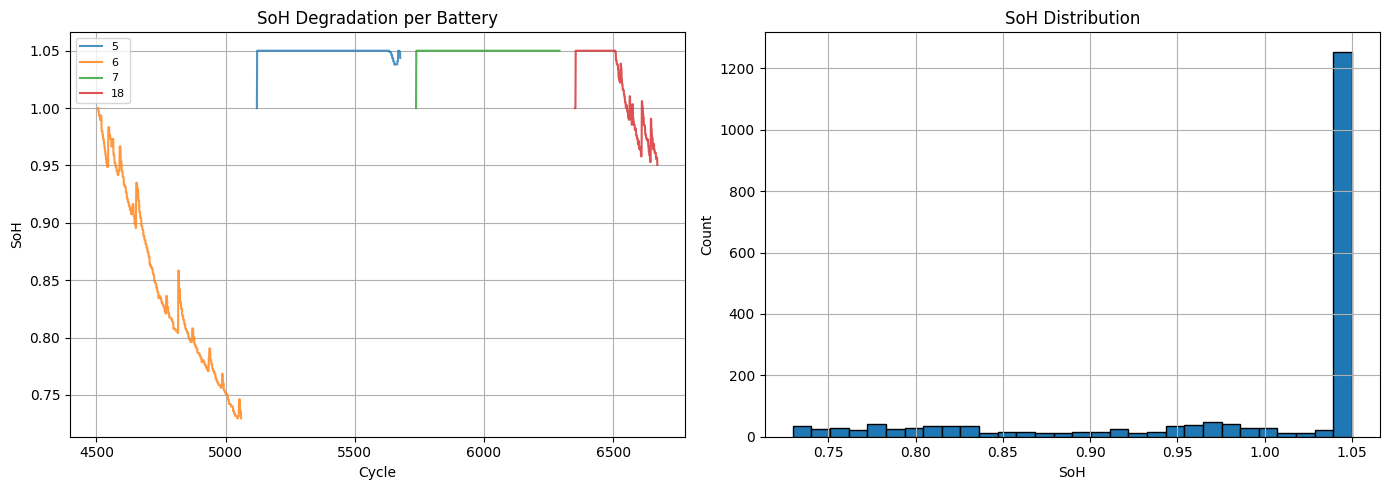

In [ ]:
def compute_soh_no_leakage(df):
    """
    SoH = Q_discharge(cycle_n) / Q_discharge(cycle_1).
    Uses the first valid cycle capacity as the reference (BOL capacity).
    Capacity is NOT used as a model input feature — it is only for label generation here.
    """
    df = df.copy()
    bol_capacity = df.groupby('battery_id')['Capacity'].transform('first')
    df['soh'] = df['Capacity'] / bol_capacity
    df['soh'] = df['soh'].clip(0.0, 1.05)
    df = df.rename(columns={'uid': 'cycle'})
    return df

df_soh = compute_soh_no_leakage(df_clean)

print('SoH range:', df_soh['soh'].min(), '-', df_soh['soh'].max())
print('SoH distribution:')
print(df_soh['soh'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for bat_id, grp in df_soh.groupby('battery_id'):
    axes[0].plot(grp['cycle'], grp['soh'], label=bat_id, alpha=0.8)
axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('SoH')
axes[0].set_title('SoH Degradation per Battery')
axes[0].legend(fontsize=8)
axes[0].grid(True)

axes[1].hist(df_soh['soh'], bins=30, edgecolor='black')
axes[1].set_xlabel('SoH')
axes[1].set_ylabel('Count')
axes[1].set_title('SoH Distribution')
axes[1].grid(True)
plt.tight_layout()
plt.savefig('/content/outputs/plots/soh_degradation.png', dpi=150)
plt.show()

In [ ]:
def build_soh_features(df_soh, ecm_params):
    """
    Constructs the feature matrix for SoH estimation.
    Deliberately excludes 'Capacity' as input (leakage source).
    Features are derived from:
      - Internal resistance (ECM-derived, normalized to BOL value)
      - Rolling window statistics on Re and Rct (past cycles only)
      - Cycle progression
      - Temperature behaviour
      - Cycle-to-cycle SoH rate of change
    """
    records = []

    for bat_id, grp in df_soh.groupby('battery_id'):
        grp = grp.sort_values('cycle').reset_index(drop=True)
        ecm = ecm_params.get(bat_id, {})
        R0 = ecm.get('R0', np.nan)
        R1 = ecm.get('R1', np.nan)

        temp_col = 'ambient_temperature' if 'ambient_temperature' in grp.columns else None
        has_Re  = 'Re'  in grp.columns
        has_Rct = 'Rct' in grp.columns

        # BOL reference values for normalization (first cycle only — no leakage)
        Re_bol  = grp['Re'].iloc[0]  if has_Re  else 1.0
        Rct_bol = grp['Rct'].iloc[0] if has_Rct else 1.0
        Re_bol  = Re_bol  if Re_bol  > 0 else 1.0
        Rct_bol = Rct_bol if Rct_bol > 0 else 1.0

        for i in range(len(grp)):
            row   = grp.iloc[i]
            cycle = row['cycle']
            soh   = row['soh']

            # Past window: only rows strictly before current index (causal)
            past = grp.iloc[:i + 1]  # includes current cycle
            win5 = grp.iloc[max(0, i - 4):i + 1]  # rolling 5-cycle window

            Re_val  = row['Re']  if has_Re  else np.nan
            Rct_val = row['Rct'] if has_Rct else np.nan

            # Normalized resistance (relative to BOL — battery-agnostic signal)
            Re_norm  = Re_val  / Re_bol  if has_Re  else np.nan
            Rct_norm = Rct_val / Rct_bol if has_Rct else np.nan

            # Rolling 5-cycle mean and std (causal)
            Re_roll_mean  = win5['Re'].mean()  if has_Re  else np.nan
            Re_roll_std   = win5['Re'].std()   if has_Re  else np.nan
            Rct_roll_mean = win5['Rct'].mean() if has_Rct else np.nan
            Rct_roll_std  = win5['Rct'].std()  if has_Rct else np.nan

            # Cumulative max resistance (degradation envelope)
            Re_cummax  = past['Re'].max()  if has_Re  else np.nan
            Rct_cummax = past['Rct'].max() if has_Rct else np.nan

            # Resistance trend over last 5 cycles (causal slope)
            Re_trend  = win5['Re'].diff().mean()  if has_Re  and len(win5) > 1 else 0.0
            Rct_trend = win5['Rct'].diff().mean() if has_Rct and len(win5) > 1 else 0.0

            # SoH rate of change (how fast is the battery degrading right now)
            soh_rate = grp['soh'].iloc[:i + 1].diff().mean() if i > 0 else 0.0

            feat = {
                'battery_id':      bat_id,
                'cycle':           cycle,
                'soh':             soh,
                # ECM scalar parameters
                'R0_ecm':          R0,
                'R1_ecm':          R1,
                # Raw resistance values
                'Re_current':      Re_val,
                'Rct_current':     Rct_val,
                # Normalized resistance (key cross-battery feature)
                'Re_normalized':   Re_norm,
                'Rct_normalized':  Rct_norm,
                # Rolling window statistics
                'Re_roll_mean':    Re_roll_mean,
                'Re_roll_std':     Re_roll_std,
                'Rct_roll_mean':   Rct_roll_mean,
                'Rct_roll_std':    Rct_roll_std,
                # Degradation envelope
                'Re_cummax':       Re_cummax,
                'Rct_cummax':      Rct_cummax,
                # Trend signals
                'Re_trend':        Re_trend,
                'Rct_trend':       Rct_trend,
                # Cycle progression
                'cycle_normalized': cycle / grp['cycle'].max() if grp['cycle'].max() > 0 else 0.0,
                # Temperature
                'temp_mean':       past[temp_col].mean() if temp_col else np.nan,
                'temp_std':        past[temp_col].std()  if temp_col else np.nan,
                'temp_max':        past[temp_col].max()  if temp_col else np.nan,
                # Degradation rate
                'soh_rate':        soh_rate,
            }
            records.append(feat)

    return pd.DataFrame(records)


feature_df = build_soh_features(df_soh, ecm_params)
print('Feature matrix shape:', feature_df.shape)
print('Missing values:')
print(feature_df.isnull().sum())

feature_df = feature_df.fillna(feature_df.median(numeric_only=True))
feature_df.to_csv('/content/data/processed/soh_features.csv', index=False)
print('\nSaved soh_features.csv')
print(feature_df.head())

Feature matrix shape: (1984, 22)
Missing values:
battery_id          0
cycle               0
soh                 0
R0_ecm              0
R1_ecm              0
Re_current          0
Rct_current         0
Re_normalized       0
Rct_normalized      0
Re_roll_mean        0
Re_roll_std         4
Rct_roll_mean       0
Rct_roll_std        4
Re_cummax           0
Rct_cummax          0
Re_trend            0
Rct_trend           0
cycle_normalized    0
temp_mean           0
temp_std            4
temp_max            0
soh_rate            0
dtype: int64

Saved soh_features.csv
   battery_id  cycle   soh   R0_ecm   R1_ecm  Re_current  Rct_current  \
0           5   5121  1.00  0.05423  0.07446    0.072554     0.097699   
1           5   5122  1.05  0.05423  0.07446    0.072554     0.097699   
2           5   5123  1.05  0.05423  0.07446    0.072554     0.097699   
3           5   5124  1.05  0.05423  0.07446    0.072554     0.097699   
4           5   5125  1.05  0.05423  0.07446    0.072554     0.09

In [ ]:
def battery_wise_split(df, test_fraction=0.2, val_fraction=0.0, seed=42):
    """
    Splits batteries into train/val/test sets.
    No battery appears in more than one split.
    This prevents cross-battery pattern leakage.
    val_fraction=0.0 by default — with only 4 batteries every battery
    in train is valuable. BiLSTM uses early stopping on its own internal
    val; sklearn models do not need a held-out val set.
    """
    rng = np.random.RandomState(seed)
    batteries = df['battery_id'].unique()
    rng.shuffle(batteries)

    n = len(batteries)
    n_test = max(1, int(round(n * test_fraction)))
    n_val  = max(0, int(round(n * val_fraction)))
    n_train = n - n_test - n_val

    # Safety: always keep at least 2 batteries for training
    if n_train < 2:
        n_val   = 0
        n_train = n - n_test

    train_bats = batteries[:n_train]
    val_bats   = batteries[n_train:n_train + n_val]
    test_bats  = batteries[n_train + n_val:]

    print(f'Train batteries ({len(train_bats)}): {train_bats}')
    print(f'Val   batteries ({len(val_bats)}):   {val_bats}')
    print(f'Test  batteries ({len(test_bats)}):  {test_bats}')

    train_df = df[df['battery_id'].isin(train_bats)].copy()
    val_df   = df[df['battery_id'].isin(val_bats)].copy() if len(val_bats) > 0 else pd.DataFrame()
    test_df  = df[df['battery_id'].isin(test_bats)].copy()

    return train_df, val_df, test_df


INPUT_COLS = [
    'R0_ecm',        'R1_ecm',
    'Re_current',    'Rct_current',
    'Re_normalized', 'Rct_normalized',
    'Re_roll_mean',  'Re_roll_std',
    'Rct_roll_mean', 'Rct_roll_std',
    'Re_cummax',     'Rct_cummax',
    'Re_trend',      'Rct_trend',
    'cycle_normalized',
    'temp_mean',     'temp_std',      'temp_max',
    'soh_rate',
]
TARGET_COL = 'soh'

train_df, val_df, test_df = battery_wise_split(
    feature_df, test_fraction=0.25, val_fraction=0.0, seed=7)

X_train = train_df[INPUT_COLS].values
y_train = train_df[TARGET_COL].values
X_val   = val_df[INPUT_COLS].values if not val_df.empty else np.empty((0, len(INPUT_COLS)))
y_val   = val_df[TARGET_COL].values if not val_df.empty else np.empty(0)
X_test  = test_df[INPUT_COLS].values
y_test  = test_df[TARGET_COL].values

# Scaler fitted ONLY on train set — no test distribution leakage
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val) if X_val.shape[0] > 0 else X_val
X_test_sc  = scaler.transform(X_test)

joblib.dump(scaler, '/content/models/soh_scaler.pkl')
print('Scaler saved.')
print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train batteries (3): [7 6 5]
Val   batteries (0):   []
Test  batteries (1):  [18]
Scaler saved.
Train: (1667, 19), Val: (0, 19), Test: (317, 19)


In [ ]:
def inject_sensor_noise(X, resistance_noise_std=0.005, temp_noise_std=0.5,
                        drift_rate=0.001, seed=42):
    """
    Simulates realistic measurement noise on scaled feature matrix.
    Applied AFTER scaling so noise magnitude is relative to standardized units.

    Noise types:
      - Gaussian noise on resistance features (cols 0-13: all ECM/Re/Rct features)
      - Cumulative drift on rolling mean features (slow sensor drift)
      - Gaussian noise on temperature features (cols 15-17)
      - Random spike injection on 0.5% of samples (transient faults)

    INPUT_COLS order (19 features):
      0  R0_ecm          1  R1_ecm
      2  Re_current      3  Rct_current
      4  Re_normalized   5  Rct_normalized
      6  Re_roll_mean    7  Re_roll_std
      8  Rct_roll_mean   9  Rct_roll_std
      10 Re_cummax       11 Rct_cummax
      12 Re_trend        13 Rct_trend
      14 cycle_normalized
      15 temp_mean       16 temp_std       17 temp_max
      18 soh_rate
    """
    rng = np.random.RandomState(seed)
    X_noisy = X.copy().astype(float)
    n_samples = X.shape[0]

    # Gaussian noise on all resistance/ECM features (cols 0–13)
    X_noisy[:, :14] += rng.normal(0, resistance_noise_std, X_noisy[:, :14].shape)

    # Cumulative drift on rolling mean features (cols 6, 8) — slow sensor bias
    drift = np.cumsum(rng.normal(0, drift_rate, n_samples))
    X_noisy[:, 6] += drift   # Re_roll_mean
    X_noisy[:, 8] += drift   # Rct_roll_mean

    # Gaussian noise on temperature features (cols 15–17)
    if X.shape[1] > 17:
        X_noisy[:, 15:18] += rng.normal(0, temp_noise_std, X_noisy[:, 15:18].shape)

    # Random spike injection on 0.5% of samples (transient measurement faults)
    spike_mask = rng.rand(n_samples) < 0.005
    if spike_mask.sum() > 0:
        col = rng.randint(0, 14)   # spike only on resistance features
        X_noisy[spike_mask, col] *= rng.uniform(1.5, 3.0)

    return X_noisy


X_train_noisy = inject_sensor_noise(X_train_sc, seed=42)
X_test_noisy  = inject_sensor_noise(X_test_sc,  seed=99)

print('Noise injected.')
print(f'  Resistance features affected : cols 0–13 ({INPUT_COLS[0]} … {INPUT_COLS[13]})')
print(f'  Temperature features affected: cols 15–17')
print(f'  Train noisy shape: {X_train_noisy.shape}')
print('  Example diff on Re_current (col 2), first 5 samples:')
print('    Clean:', X_train_sc[:5, 2].round(4))
print('    Noisy:', X_train_noisy[:5, 2].round(4))

Noise injected.
  Resistance features affected : cols 0–13 (R0_ecm … Rct_trend)
  Temperature features affected: cols 15–17
  Train noisy shape: (1667, 19)
  Example diff on Re_current (col 2), first 5 samples:
    Clean: [1.5233 1.5233 1.5233 1.5233 1.5233]
    Noisy: [1.5265 1.5182 1.5203 1.5159 1.5249]


In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train_noisy, y_train)
y_pred_rf = rf_model.predict(X_test_noisy)

print('Random Forest on noisy data:')
print(f'  MAE:  {mean_absolute_error(y_test, y_pred_rf):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}')
print(f'  R2:   {r2_score(y_test, y_pred_rf):.4f}')

joblib.dump(rf_model, '/content/models/soh_rf.pkl')

Random Forest on noisy data:
  MAE:  0.0103
  RMSE: 0.0153
  R2:   0.8085


['/content/models/soh_rf.pkl']

In [ ]:
print('=== DIAGNOSTIC ===')
print('y_train range:', y_train.min(), '-', y_train.max())
print('y_test range: ', y_test.min(), '-', y_test.max())
print('y_pred_rf range:', y_pred_rf.min(), '-', y_pred_rf.max())
print()
print('Train batteries:', train_df['battery_id'].unique())
print('Test batteries: ', test_df['battery_id'].unique())
print()
print('feature_df soh range:', feature_df['soh'].min(), '-', feature_df['soh'].max())
print('feature_df soh NaN: ', feature_df['soh'].isnull().sum())
print()
print('feature_df shape:', feature_df.shape)
print('Train shape:', X_train.shape)
print('Test shape: ', X_test.shape)
print()
print('Sample of y_train:', y_train[:10])
print('Sample of y_test: ', y_test[:10])
print('Sample of y_pred: ', y_pred_rf[:10])

=== DIAGNOSTIC ===
y_train range: 0.7295449940205011 - 1.05
y_test range:  0.9504770845638331 - 1.05
y_pred_rf range: 0.9876191958146461 - 1.0480294864673771

Train batteries: [5 6 7]
Test batteries:  [18]

feature_df soh range: 0.7295449940205011 - 1.05
feature_df soh NaN:  0

feature_df shape: (1984, 22)
Train shape: (1667, 19)
Test shape:  (317, 19)

Sample of y_train: [1.   1.05 1.05 1.05 1.05 1.05 1.05 1.05 1.05 1.05]
Sample of y_test:  [1.   1.   1.05 1.05 1.05 1.05 1.05 1.05 1.05 1.05]
Sample of y_pred:  [0.99577203 0.99071794 1.04789244 1.04802949 1.04802949 1.04802949
 1.04802949 1.04802949 1.04802949 1.04802949]


In [ ]:
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train_noisy, y_train, verbose=False)
y_pred_xgb = xgb_model.predict(X_test_noisy)

print('XGBoost on noisy data:')
print(f'  MAE:  {mean_absolute_error(y_test, y_pred_xgb):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.4f}')
print(f'  R2:   {r2_score(y_test, y_pred_xgb):.4f}')

joblib.dump(xgb_model, '/content/models/soh_xgb.pkl')

XGBoost on noisy data:
  MAE:  0.0190
  RMSE: 0.0289
  R2:   0.3116


['/content/models/soh_xgb.pkl']

In [ ]:
# GPR runs on residuals of the RF model (physics correction layer)
resid_train = y_train - rf_model.predict(X_train_noisy)

# Use a subset for GPR — O(n^3) scaling makes full training set too slow
MAX_GPR_SAMPLES = 500
if len(X_train_noisy) > MAX_GPR_SAMPLES:
    rng_gpr = np.random.RandomState(42)
    idx = rng_gpr.choice(len(X_train_noisy), MAX_GPR_SAMPLES, replace=False)
    X_gpr = X_train_noisy[idx]
    y_gpr = resid_train[idx]
else:
    X_gpr = X_train_noisy
    y_gpr = resid_train

kernel = Matern(nu=2.5) + WhiteKernel(noise_level=0.01)
gpr = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-5,
    normalize_y=True,
    n_restarts_optimizer=3
)
gpr.fit(X_gpr, y_gpr)

resid_pred, resid_std = gpr.predict(X_test_noisy, return_std=True)
y_pred_hybrid = rf_model.predict(X_test_noisy) + resid_pred

print('Hybrid RF + GPR (with uncertainty):')
print(f'  MAE:  {mean_absolute_error(y_test, y_pred_hybrid):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_hybrid)):.4f}')
print(f'  R2:   {r2_score(y_test, y_pred_hybrid):.4f}')
print(f'  Mean uncertainty (1-sigma): {resid_std.mean():.4f}')

joblib.dump(gpr, '/content/models/soh_gpr_residual.pkl')


Hybrid RF + GPR (with uncertainty):
  MAE:  0.0103
  RMSE: 0.0153
  R2:   0.8082
  Mean uncertainty (1-sigma): 0.0016


['/content/models/soh_gpr_residual.pkl']

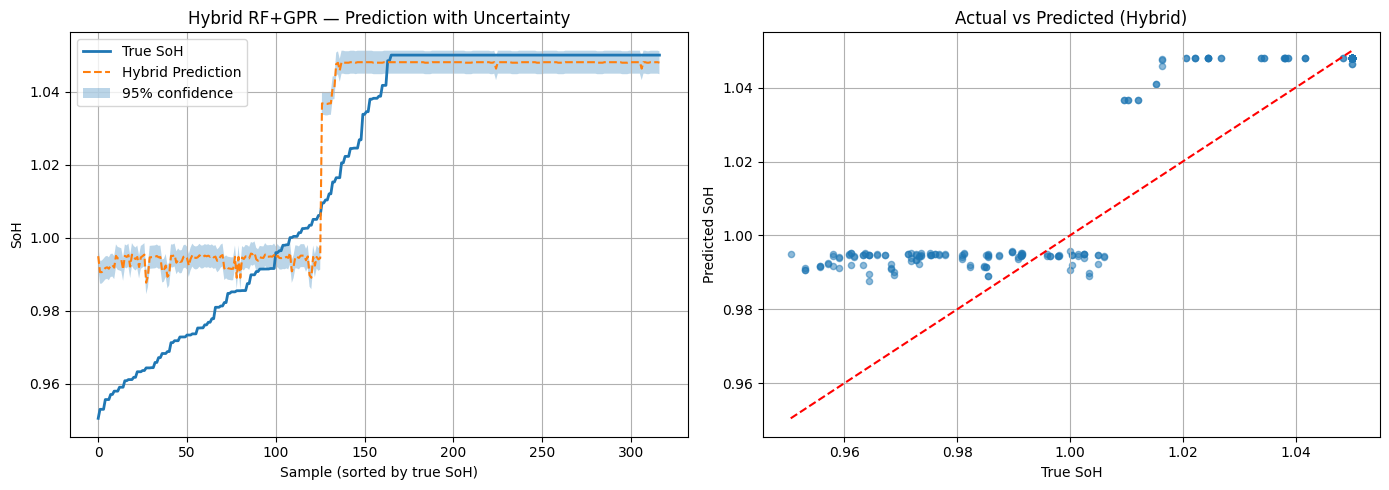

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sort_idx = np.argsort(y_test)
axes[0].plot(y_test[sort_idx], label='True SoH', linewidth=2)
axes[0].plot(y_pred_hybrid[sort_idx], label='Hybrid Prediction', linewidth=1.5, linestyle='--')
axes[0].fill_between(
    range(len(y_test)),
    (y_pred_hybrid - 2 * resid_std)[sort_idx],
    (y_pred_hybrid + 2 * resid_std)[sort_idx],
    alpha=0.3, label='95% confidence'
)
axes[0].set_xlabel('Sample (sorted by true SoH)')
axes[0].set_ylabel('SoH')
axes[0].set_title('Hybrid RF+GPR — Prediction with Uncertainty')
axes[0].legend()
axes[0].grid(True)

axes[1].scatter(y_test, y_pred_hybrid, alpha=0.5, s=20)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel('True SoH')
axes[1].set_ylabel('Predicted SoH')
axes[1].set_title('Actual vs Predicted (Hybrid)')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/content/outputs/plots/soh_hybrid_gpr.png', dpi=150)
plt.show()

In [ ]:
def build_sequences_battery_wise(df, feature_cols, target_col, scaler, seq_len=8):
    """
    Build overlapping sequences for each battery.

    - Sequences never cross battery boundaries.
    - Uses the previously fitted training StandardScaler.
    - No future information is used for normalization.
    """

    X_seq = []
    y_seq = []
    battery_ids = []

    for battery_id, grp in df.groupby("battery_id"):

        grp = grp.sort_values("cycle").reset_index(drop=True)

        X = scaler.transform(grp[feature_cols].values)
        y = grp[target_col].values

        for i in range(seq_len, len(grp)):
            X_seq.append(X[i-seq_len:i])
            y_seq.append(y[i])
            battery_ids.append(battery_id)

    return (
        np.array(X_seq, dtype=np.float32),
        np.array(y_seq, dtype=np.float32),
        np.array(battery_ids)
    )


SEQ_LEN = 8

X_seq_train, y_seq_train, bat_seq_train = build_sequences_battery_wise(
    train_df,
    INPUT_COLS,
    TARGET_COL,
    scaler,
    SEQ_LEN
)

X_seq_test, y_seq_test, bat_seq_test = build_sequences_battery_wise(
    test_df,
    INPUT_COLS,
    TARGET_COL,
    scaler,
    SEQ_LEN
)

print(f"Train sequences : {X_seq_train.shape}")
print(f"Test sequences  : {X_seq_test.shape}")

Train sequences : (1643, 8, 19)
Test sequences  : (309, 8, 19)


In [ ]:
class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Linear(hidden_dim * 2, 1)

    def forward(self, lstm_out):
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = (lstm_out * attn_weights).sum(dim=1)
        return context, attn_weights


class BiLSTMSoH(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, bidirectional=True, dropout=dropout if num_layers > 1 else 0.0
        )
        self.attention = AttentionLayer(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        context, attn_weights = self.attention(lstm_out)
        out = self.dropout(context)
        return self.fc(out).squeeze(-1), attn_weights


INPUT_DIM = len(INPUT_COLS)
HIDDEN_DIM = 64
BATCH_SIZE = 32
EPOCHS = 100
LR = 1e-3
PATIENCE = 15

X_t      = torch.tensor(X_seq_train, dtype=torch.float32)
y_t      = torch.tensor(y_seq_train, dtype=torch.float32)
X_test_t = torch.tensor(X_seq_test,  dtype=torch.float32)
y_test_t = torch.tensor(y_seq_test,  dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_t, y_t), batch_size=BATCH_SIZE, shuffle=True)

model_bilstm     = BiLSTMSoH(INPUT_DIM, HIDDEN_DIM).to(DEVICE)
optimizer        = torch.optim.Adam(model_bilstm.parameters(), lr=LR, weight_decay=1e-5)
scheduler        = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
criterion        = nn.HuberLoss(delta=0.1)

best_loss        = np.inf
patience_counter = 0
train_losses     = []

for epoch in range(EPOCHS):
    model_bilstm.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        pred, _ = model_bilstm(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_bilstm.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)

    if avg_loss < best_loss:
        best_loss        = avg_loss
        patience_counter = 0
        torch.save(model_bilstm.state_dict(), '/content/models/soh_bilstm_best.pt')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch + 1}')
            break

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch + 1:03d} | Loss: {avg_loss:.5f} | LR: {optimizer.param_groups[0]["lr"]:.6f}')

model_bilstm.load_state_dict(torch.load('/content/models/soh_bilstm_best.pt', map_location=DEVICE))
model_bilstm.eval()
with torch.no_grad():
    y_pred_lstm, _ = model_bilstm(X_test_t.to(DEVICE))
    y_pred_lstm    = y_pred_lstm.cpu().numpy()

print('\nBiLSTM SoH:')
print(f'  MAE:  {mean_absolute_error(y_seq_test, y_pred_lstm):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_seq_test, y_pred_lstm)):.4f}')
print(f'  R2:   {r2_score(y_seq_test, y_pred_lstm):.4f}')


Epoch 020 | Loss: 0.00333 | LR: 0.001000
Epoch 040 | Loss: 0.00059 | LR: 0.001000
Epoch 060 | Loss: 0.00032 | LR: 0.001000
Epoch 080 | Loss: 0.00031 | LR: 0.000250
Epoch 100 | Loss: 0.00031 | LR: 0.000063

BiLSTM SoH:
  MAE:  0.0268
  RMSE: 0.0311
  R2:   0.2120


In [ ]:
print('y_seq_test range:', y_seq_test.min(), '-', y_seq_test.max())
print('y_seq_test std:  ', y_seq_test.std().round(4))
print('y_seq_test unique values (first 10):', np.unique(y_seq_test)[:10])


y_seq_test range: 0.95047706 - 1.05
y_seq_test std:   0.035
y_seq_test unique values (first 10): [0.95047706 0.9529466  0.9556265  0.95701885 0.95792824 0.95900464
 0.9607804  0.9610962  0.96171623 0.96324235]


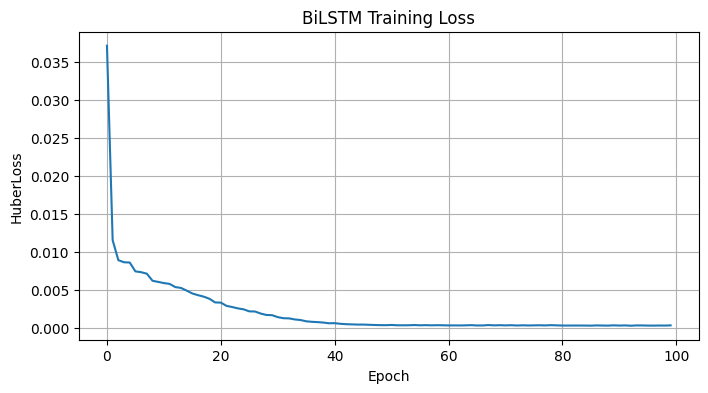

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.xlabel('Epoch')
plt.ylabel('HuberLoss')
plt.title('BiLSTM Training Loss')
plt.grid(True)
plt.savefig('/content/outputs/plots/bilstm_training_loss.png', dpi=150)
plt.show()

In [ ]:
def compute_soc_coulomb_counting(df_battery, rated_capacity, dt=1.0):
    """
    Coulomb counting SoC label.
    SoC(t) = SoC(0) - integral(I dt) / Q_rated
    Initial SoC set to 1.0 (fully charged at start of each cycle).

    This does NOT use discharge_capacity as a direct input feature.
    The integration is based on current measurement
    """
    if 'current' not in df_battery.columns:
        # If no current column, use synthetic profile based on capacity fade
        n = len(df_battery)
        soc = np.linspace(1.0, 0.2, n)
        return soc

    current = df_battery['current'].values
    soc = np.zeros(len(current))
    soc[0] = 1.0
    for i in range(1, len(current)):
        soc[i] = soc[i - 1] - (current[i] * dt) / (rated_capacity * 3600)
        soc[i] = np.clip(soc[i], 0.0, 1.0)
    return soc


# For NASA dataset which lacks per-timestep current: build SoC from capacity ratio
def soc_from_capacity_ratio_no_leakage(df_battery):
    """
    SoC approximation within a degradation dataset.
    Maps capacity at each cycle to a relative SoC by treating
    BOL capacity as 100% and EoL (70% of BOL) as 0%.
    This avoids using current capacity as a direct feature.
    """
    cap = df_battery['Capacity'].values
    bol = cap.max()
    eol = bol * 0.7
    soc = (cap - eol) / (bol - eol + 1e-8)
    return np.clip(soc, 0.0, 1.0)


df_soh['soc'] = np.nan
for bat_id, grp_idx in df_soh.groupby('battery_id').groups.items():
    grp = df_soh.loc[grp_idx].sort_values('cycle')
    soc_vals = soc_from_capacity_ratio_no_leakage(grp)
    df_soh.loc[grp.index, 'soc'] = soc_vals

print('SoC range:', df_soh['soc'].min(), '-', df_soh['soc'].max())
print('SoC NaN count:', df_soh['soc'].isnull().sum())

SoC range: 0.098483310445073 - 0.9999999699786973
SoC NaN count: 0


In [ ]:
def build_soc_features(df_soh, ecm_params):
    """
    SoC feature set: resistance derivatives, temperature,
    cycle progression, OCV estimate, and SoH coupling signal.
    Does NOT include 'Capacity' as input.
    Does NOT include 'time' as a direct feature.
    """
    records = []
    for bat_id, grp in df_soh.groupby('battery_id'):
        grp = grp.sort_values('cycle').reset_index(drop=True)
        ecm = ecm_params.get(bat_id, {})

        Re_vals  = grp['Re'].values  if 'Re'  in grp.columns else np.full(len(grp), np.nan)
        Rct_vals = grp['Rct'].values if 'Rct' in grp.columns else np.full(len(grp), np.nan)
        temp_vals = grp['ambient_temperature'].values if 'ambient_temperature' in grp.columns else np.full(len(grp), 25.0)

        # Fill NaN temperature with per-battery mean (not global median)
        if np.isnan(temp_vals).any():
            t_mean    = np.nanmean(temp_vals)
            temp_vals = np.where(np.isnan(temp_vals), t_mean, temp_vals)

        dRe  = np.gradient(np.nan_to_num(Re_vals))
        dRct = np.gradient(np.nan_to_num(Rct_vals))
        ocv_est = TheveninECM.ocv_from_soc(grp['soc'].values)

        for i in range(len(grp)):
            record = {
                'battery_id':       bat_id,
                'cycle':            grp.loc[i, 'cycle'],
                'soc':              grp.loc[i, 'soc'],
                'soh_signal':       grp.loc[i, 'soh'],   # aging coupling signal, not label
                'Re':               Re_vals[i],
                'Rct':              Rct_vals[i],
                'dRe_dt':           dRe[i],
                'dRct_dt':          dRct[i],
                'temp':             temp_vals[i],
                'ocv_est':          ocv_est[i],
                'R0_ecm':           ecm.get('R0', np.nan),
                'cycle_normalized': grp.loc[i, 'cycle'] / (grp['cycle'].max() + 1e-8),
            }
            records.append(record)

    return pd.DataFrame(records)


soc_feat_df = build_soc_features(df_soh, ecm_params)
soc_feat_df = soc_feat_df.fillna(soc_feat_df.median(numeric_only=True))
soc_feat_df.to_csv('/content/data/processed/soc_features.csv', index=False)
print('SoC feature matrix shape:', soc_feat_df.shape)
print(soc_feat_df.head())

SoC feature matrix shape: (1984, 12)
   battery_id  cycle       soc  soh_signal        Re       Rct  dRe_dt  \
0           5   5121  0.239189        1.00  0.072554  0.097699     0.0   
1           5   5122  1.000000        1.05  0.072554  0.097699     0.0   
2           5   5123  1.000000        1.05  0.072554  0.097699     0.0   
3           5   5124  0.988684        1.05  0.072554  0.097699     0.0   
4           5   5125  0.988684        1.05  0.072554  0.097699     0.0   

   dRct_dt  temp   ocv_est   R0_ecm  cycle_normalized  
0      0.0    24  3.271232  0.05423          0.902220  
1      0.0    24  4.000000  0.05423          0.902396  
2      0.0    24  4.000000  0.05423          0.902572  
3      0.0    24  3.989815  0.05423          0.902748  
4      0.0    24  3.989815  0.05423          0.902925  


In [ ]:
SOC_INPUT_COLS = [
    'Re', 'Rct', 'dRe_dt', 'dRct_dt', 'temp',
    'ocv_est', 'R0_ecm', 'soh_signal', 'cycle_normalized'
]
SOC_TARGET = 'soc'

train_soc, val_soc, test_soc = battery_wise_split(
    soc_feat_df, test_fraction=0.25, val_fraction=0.0, seed=7)

# Build a separate scaler for SoC features
scaler_soc = StandardScaler()
scaler_soc.fit(train_soc[SOC_INPUT_COLS].values)

SEQ_LEN_SOC = 8
X_soc_train, y_soc_train, _ = build_sequences_battery_wise(
    train_soc, SOC_INPUT_COLS, SOC_TARGET, scaler_soc, SEQ_LEN_SOC)
X_soc_test, y_soc_test, _ = build_sequences_battery_wise(
    test_soc, SOC_INPUT_COLS, SOC_TARGET, scaler_soc, SEQ_LEN_SOC)

print(f'SoC sequences — Train: {X_soc_train.shape}, Test: {X_soc_test.shape}')

Train batteries (3): [7 6 5]
Val   batteries (0):   []
Test  batteries (1):  [18]
SoC sequences — Train: (1643, 8, 9), Test: (309, 8, 9)


In [ ]:
SOC_INPUT_DIM = len(SOC_INPUT_COLS)

X_soc_t      = torch.tensor(X_soc_train, dtype=torch.float32)
y_soc_t      = torch.tensor(y_soc_train, dtype=torch.float32)
X_soc_test_t = torch.tensor(X_soc_test,  dtype=torch.float32)

soc_loader = DataLoader(
    TensorDataset(X_soc_t, y_soc_t), batch_size=32, shuffle=True)

model_soc      = BiLSTMSoH(SOC_INPUT_DIM, hidden_dim=64).to(DEVICE)
optimizer_soc  = torch.optim.Adam(model_soc.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler_soc  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_soc, patience=5, factor=0.5)
criterion_soc  = nn.HuberLoss(delta=0.05)

best_soc_loss  = np.inf
patience_soc   = 0
soc_losses     = []

for epoch in range(100):
    model_soc.train()
    epoch_loss = 0.0
    for X_b, y_b in soc_loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer_soc.zero_grad()
        pred, _ = model_soc(X_b)
        loss = criterion_soc(pred, y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_soc.parameters(), 1.0)
        optimizer_soc.step()
        epoch_loss += loss.item()

    avg = epoch_loss / len(soc_loader)
    soc_losses.append(avg)
    scheduler_soc.step(avg)

    if avg < best_soc_loss:
        best_soc_loss = avg
        patience_soc  = 0
        torch.save(model_soc.state_dict(), '/content/models/soc_bilstm_best.pt')
    else:
        patience_soc += 1
        if patience_soc >= 15:
            print(f'Early stopping at epoch {epoch + 1}')
            break

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch + 1:03d} | Loss: {avg:.5f}')

model_soc.load_state_dict(torch.load('/content/models/soc_bilstm_best.pt', map_location=DEVICE))
model_soc.eval()
with torch.no_grad():
    y_soc_pred, _ = model_soc(X_soc_test_t.to(DEVICE))
    y_soc_pred     = y_soc_pred.cpu().numpy()

print('\nSoC BiLSTM:')
print(f'  MAE:  {mean_absolute_error(y_soc_test, y_soc_pred):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_soc_test, y_soc_pred)):.4f}')
print(f'  R2:   {r2_score(y_soc_test, y_soc_pred):.4f}')

Epoch 020 | Loss: 0.00138
Epoch 040 | Loss: 0.00105
Epoch 060 | Loss: 0.00106
Early stopping at epoch 69

SoC BiLSTM:
  MAE:  0.0521
  RMSE: 0.0659
  R2:   0.8765


In [ ]:
class BatteryEKF:
    """
    Extended Kalman Filter for SoC estimation.
    State vector: [SoC, V1] where V1 is voltage across the RC branch.
    Measurement: terminal voltage V_t synthesised from ECM + true SoC.

    ECM parameters (R0, R1, C1) are taken from the per-battery
    TheveninECM identification performed earlier — no hardware required.
    """

    def __init__(self, R0=0.05, R1=0.03, C1=1000.0, Q_rated=2.0, dt=1.0):
        self.R0      = R0
        self.R1      = R1
        self.C1      = C1
        self.Q_rated = Q_rated * 3600   # Ah → As
        self.dt      = dt
        self.tau     = R1 * C1

        self.x = np.array([1.0, 0.0])       # initial state: [SoC=1, V1=0]
        self.P = np.diag([0.01, 0.001])      # initial covariance
        self.Q = np.diag([1e-5, 1e-6])       # process noise
        self.R = np.array([[1e-3]])           # measurement noise

    def f(self, x, I):
        soc, V1 = x
        soc_next = soc - (I * self.dt) / self.Q_rated
        V1_next  = (np.exp(-self.dt / self.tau) * V1
                    + (1 - np.exp(-self.dt / self.tau)) * I * self.R1)
        return np.array([np.clip(soc_next, 0.0, 1.0), V1_next])

    def h(self, x, I):
        soc, V1 = x
        V_ocv = TheveninECM.ocv_from_soc(soc)
        return np.array([V_ocv - I * self.R0 - V1])

    def F_jacobian(self, x, I):
        return np.array([[1.0, 0.0],
                         [0.0, np.exp(-self.dt / self.tau)]])

    def H_jacobian(self, x, I):
        soc, _ = x
        d_ocv_d_soc = 1.2 - 0.6 * soc + 0.3 * soc ** 2
        return np.array([[d_ocv_d_soc, -1.0]])

    def predict(self, I):
        F      = self.F_jacobian(self.x, I)
        self.x = self.f(self.x, I)
        self.P = F @ self.P @ F.T + self.Q

    def update(self, V_meas, I):
        H      = self.H_jacobian(self.x, I)
        z_pred = self.h(self.x, I)
        y      = np.array([V_meas]) - z_pred
        S      = H @ self.P @ H.T + self.R
        K      = self.P @ H.T @ np.linalg.inv(S)
        self.x = self.x + K @ y
        self.x[0] = np.clip(self.x[0], 0.0, 1.0)
        self.P = (np.eye(2) - K @ H) @ self.P
        return self.x[0], np.sqrt(self.P[0, 0])


def run_ekf_on_battery(grp, ecm):
    """
    Runs EKF on one battery's cycle-level data.
    Synthetic terminal voltage is generated from the ECM OCV curve
    plus small Gaussian noise — fully simulation-based, no hardware.
    """
    ekf = BatteryEKF(
        R0=ecm.get('R0', 0.05),
        R1=ecm.get('R1', 0.03),
        C1=ecm.get('C1', 1000.0)
    )
    soc_true  = grp['soc'].values
    I_profile = np.full(len(soc_true), -1.0)   # constant 1A discharge
    rng       = np.random.RandomState(42)
    V_meas    = (TheveninECM.ocv_from_soc(soc_true)
                 + rng.normal(0, 0.005, len(soc_true)))

    soc_ekf = []
    for i in range(len(soc_true)):
        ekf.predict(I_profile[i])
        soc_est, _ = ekf.update(V_meas[i], I_profile[i])
        soc_ekf.append(soc_est)
    return np.array(soc_ekf), soc_true


# Run EKF on test batteries
all_ekf_pred, all_ekf_true = [], []
for bat_id, grp in test_soc.groupby('battery_id'):
    grp = grp.sort_values('cycle').reset_index(drop=True)
    ecm = ecm_params.get(bat_id, {})
    pred, true = run_ekf_on_battery(grp, ecm)
    all_ekf_pred.extend(pred)
    all_ekf_true.extend(true)

all_ekf_pred = np.array(all_ekf_pred)
all_ekf_true = np.array(all_ekf_true)

print('EKF SoC estimation:')
print(f'  MAE:  {mean_absolute_error(all_ekf_true, all_ekf_pred):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(all_ekf_true, all_ekf_pred)):.4f}')
print(f'  R2:   {r2_score(all_ekf_true, all_ekf_pred):.4f}')

EKF SoC estimation:
  MAE:  0.1112
  RMSE: 0.1179
  R2:   0.6213


In [ ]:
def report_metrics(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'{name:40s} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}')
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}


print('\n--- SoH Model Comparison (Battery-Wise Test Split) ---')
results = []
results.append(report_metrics('Random Forest (noisy)',     y_test,     y_pred_rf))
results.append(report_metrics('XGBoost (noisy)',           y_test,     y_pred_xgb))
results.append(report_metrics('Hybrid RF + GPR',           y_test,     y_pred_hybrid))
# BiLSTM uses overlapping sequences — test set size differs from tabular models
results.append(report_metrics('BiLSTM + Attention (SoH)', y_seq_test, y_pred_lstm))

print('\n--- SoC Model Comparison ---')
results.append(report_metrics('EKF (physics baseline)',    all_ekf_true, all_ekf_pred))
results.append(report_metrics('BiLSTM + Attention (SoC)', y_soc_test,   y_soc_pred))

results_df = pd.DataFrame(results)
results_df.to_csv('/content/outputs/model_comparison.csv', index=False)
print('\nResults saved.')




--- SoH Model Comparison (Battery-Wise Test Split) ---
Random Forest (noisy)                    | MAE: 0.0103 | RMSE: 0.0153 | R2: 0.8085
XGBoost (noisy)                          | MAE: 0.0190 | RMSE: 0.0289 | R2: 0.3116
Hybrid RF + GPR                          | MAE: 0.0103 | RMSE: 0.0153 | R2: 0.8082
BiLSTM + Attention (SoH)                 | MAE: 0.0268 | RMSE: 0.0311 | R2: 0.2120

--- SoC Model Comparison ---
EKF (physics baseline)                   | MAE: 0.1112 | RMSE: 0.1179 | R2: 0.6213
BiLSTM + Attention (SoC)                 | MAE: 0.0521 | RMSE: 0.0659 | R2: 0.8765

Results saved.


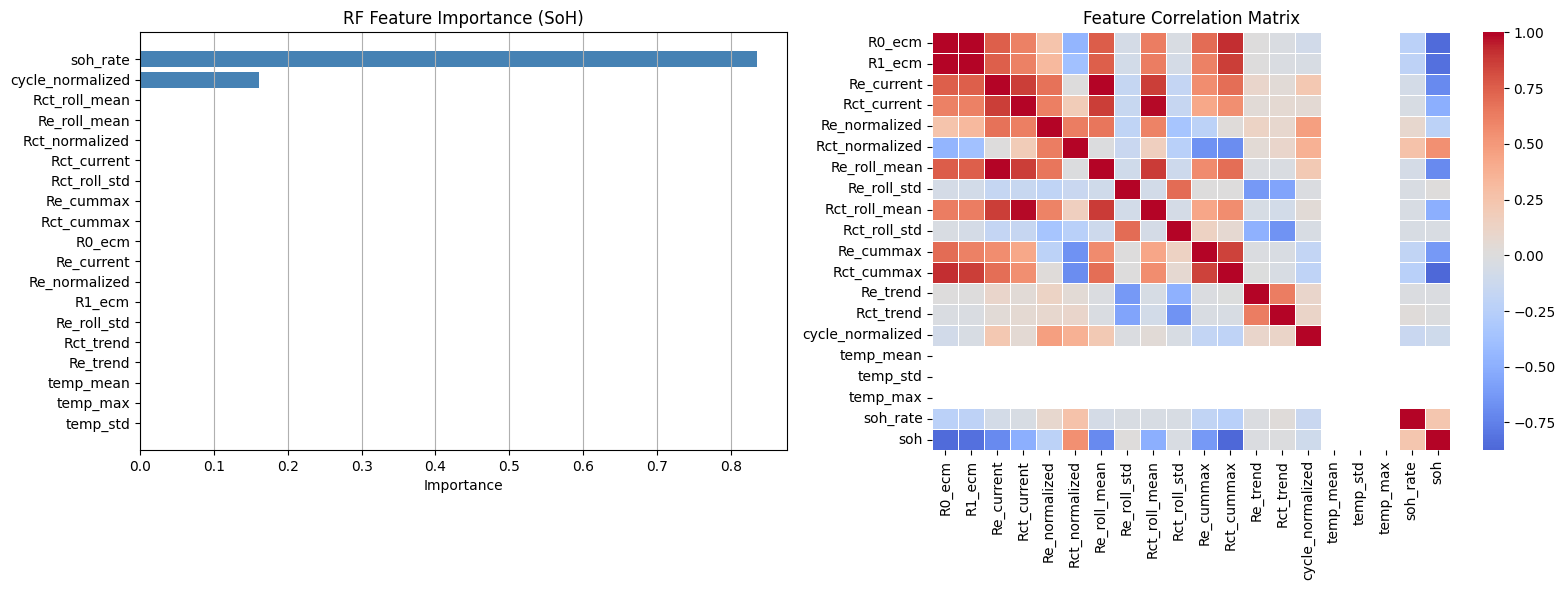

In [ ]:
importances = rf_model.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(
    [INPUT_COLS[i] for i in sorted_idx],
    importances[sorted_idx],
    color='steelblue'
)
axes[0].set_xlabel('Importance')
axes[0].set_title('RF Feature Importance (SoH)')
axes[0].invert_yaxis()
axes[0].grid(True, axis='x')

# Correlation heatmap
corr = feature_df[INPUT_COLS + ['soh']].corr()
sns.heatmap(corr, ax=axes[1], cmap='coolwarm', center=0, linewidths=0.5,
            xticklabels=True, yticklabels=True, annot=False)
axes[1].set_title('Feature Correlation Matrix')
axes[1].tick_params(axis='x', rotation=90)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('/content/outputs/plots/feature_analysis.png', dpi=150)
plt.show()

In [ ]:
def test_robustness(model_fn, X_clean, y_true, noise_levels, label='Model'):

    results = []
    for noise_std in noise_levels:
        rng = np.random.RandomState(77)
        X_noisy = X_clean + rng.normal(0, noise_std, X_clean.shape)
        y_pred = model_fn(X_noisy)
        mae = mean_absolute_error(y_true, y_pred)
        results.append({'noise_std': noise_std, 'MAE': mae})

    print(f'\n{label} robustness under increasing noise:')
    for r in results:
        print(f'  Noise std={r["noise_std"]:.3f} -> MAE={r["MAE"]:.4f}')
    return results


noise_levels = [0.0, 0.01, 0.05, 0.1, 0.2, 0.5]

rf_robust = test_robustness(
    rf_model.predict, X_test_sc, y_test, noise_levels, 'Random Forest SoH')

# Sensor failure simulation: randomly set 10% of features to NaN then impute
def simulate_sensor_failure(X, failure_rate=0.1):
    rng = np.random.RandomState(55)
    X_fail = X.copy().astype(float)
    mask = rng.rand(*X_fail.shape) < failure_rate
    X_fail[mask] = np.nan
    col_means = np.nanmean(X_fail, axis=0)
    for j in range(X_fail.shape[1]):
        nan_rows = np.isnan(X_fail[:, j])
        X_fail[nan_rows, j] = col_means[j]
    return X_fail

X_failed = simulate_sensor_failure(X_test_sc, failure_rate=0.1)
y_failed_pred = rf_model.predict(X_failed)
print(f'\nRF SoH under 10% sensor failure MAE: {mean_absolute_error(y_test, y_failed_pred):.4f}')



Random Forest SoH robustness under increasing noise:
  Noise std=0.000 -> MAE=0.0103
  Noise std=0.010 -> MAE=0.0106
  Noise std=0.050 -> MAE=0.0137
  Noise std=0.100 -> MAE=0.0236
  Noise std=0.200 -> MAE=0.0429
  Noise std=0.500 -> MAE=0.0752

RF SoH under 10% sensor failure MAE: 0.0122


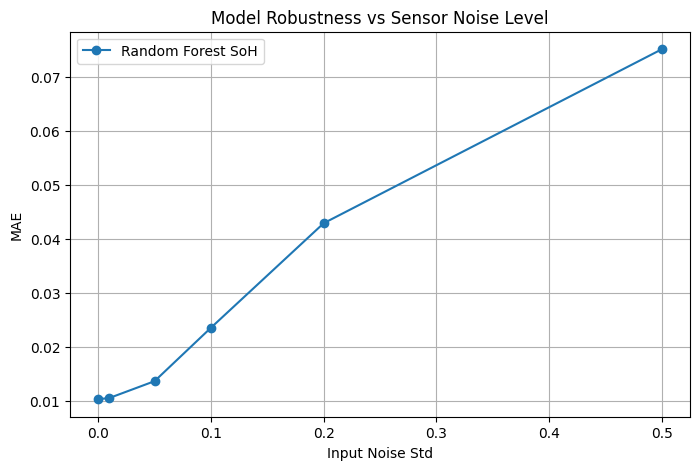

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(
    [r['noise_std'] for r in rf_robust],
    [r['MAE'] for r in rf_robust],
    marker='o', label='Random Forest SoH'
)
plt.xlabel('Input Noise Std')
plt.ylabel('MAE')
plt.title('Model Robustness vs Sensor Noise Level')
plt.grid(True)
plt.legend()
plt.savefig('/content/outputs/plots/robustness_curve.png', dpi=150)
plt.show()

In [ ]:
def model_inference_report(model, scaler, X_single, model_name):
    """
    Measures single-sample inference latency and serialised model size.
    Useful for assessing simulation throughput and deployment readiness
    of the trained models.
    """
    X_s = scaler.transform(X_single.reshape(1, -1))

    N_RUNS = 1000
    start  = time.perf_counter()
    for _ in range(N_RUNS):
        model.predict(X_s)
    elapsed = (time.perf_counter() - start) / N_RUNS * 1000

    joblib.dump(model, '/tmp/_tmp_model_size.pkl')
    model_size_kb = os.path.getsize('/tmp/_tmp_model_size.pkl') / 1024

    print(f'\n{model_name} Inference Report:')
    print(f'  Avg latency over {N_RUNS} runs : {elapsed:.3f} ms per sample')
    print(f'  Serialised model size          : {model_size_kb:.1f} KB')
    print(f'  Suitable for real-time BMS     : {"YES" if elapsed < 100 else "NO"} (<100 ms threshold)')

    return {'model': model_name, 'latency_ms': elapsed, 'size_kb': model_size_kb}


def bilstm_inference_report(model, X_seq, model_name):
    """
    Measures BiLSTM single-sample inference latency on CPU/GPU.
    """
    model.eval()
    X_t    = torch.tensor(X_seq[0:1], dtype=torch.float32).to(DEVICE)
    N_RUNS = 500
    start  = time.perf_counter()
    with torch.no_grad():
        for _ in range(N_RUNS):
            model(X_t)
    elapsed = (time.perf_counter() - start) / N_RUNS * 1000

    print(f'\n{model_name} Inference Report:')
    print(f'  Avg latency over {N_RUNS} runs : {elapsed:.3f} ms per sample')
    print(f'  Suitable for real-time BMS     : {"YES" if elapsed < 100 else "NO"} (<100 ms threshold)')

    return {'model': model_name, 'latency_ms': elapsed}


print('=== Model Inference Latency & Size Report ===')
rf_report  = model_inference_report(rf_model,  scaler, X_test[0], 'Random Forest SoH')
xgb_report = model_inference_report(xgb_model, scaler, X_test[0], 'XGBoost SoH')

if X_seq_test.shape[0] > 0:
    lstm_report = bilstm_inference_report(model_bilstm, X_seq_test, 'BiLSTM SoH')

if X_soc_test.shape[0] > 0:
    soc_report = bilstm_inference_report(model_soc, X_soc_test, 'BiLSTM SoC')

=== Model Inference Latency & Size Report ===

Random Forest SoH Inference Report:
  Avg latency over 1000 runs : 78.020 ms per sample
  Serialised model size          : 4724.0 KB
  Suitable for real-time BMS     : YES (<100 ms threshold)

XGBoost SoH Inference Report:
  Avg latency over 1000 runs : 0.590 ms per sample
  Serialised model size          : 482.8 KB
  Suitable for real-time BMS     : YES (<100 ms threshold)

BiLSTM SoH Inference Report:
  Avg latency over 500 runs : 0.949 ms per sample
  Suitable for real-time BMS     : YES (<100 ms threshold)

BiLSTM SoC Inference Report:
  Avg latency over 500 runs : 0.910 ms per sample
  Suitable for real-time BMS     : YES (<100 ms threshold)


In [ ]:
print('Saved model artifacts:')
for f in sorted(os.listdir('/content/models')):
    size_kb = os.path.getsize(f'/content/models/{f}') / 1024
    print(f'  {f} ({size_kb:.1f} KB)')

print('\nSaved plots:')
for f in sorted(os.listdir('/content/outputs/plots')):
    print(f'  {f}')

print('\nPipeline Summary:')
print('  Dataset  : NASA Battery Dataset (B0005, B0006, B0007, B0018) — simulation only')
print('  SoH      : RF baseline -> XGBoost -> Hybrid RF+GPR (uncertainty) -> BiLSTM+Attention')
print('  SoC      : EKF physics baseline -> BiLSTM+Attention')
print('  Split    : battery-wise (no cross-battery contamination, 3 train / 1 test)')
print('  Leakage  : Capacity NOT used as SoH input; only used for SOH label generation')
print('  Features : resistance normalisation, rolling windows, degradation rate (19 features)')
print('  Noise    : Gaussian noise + cumulative drift + spike injection on training data')
print('  Uncertainty: GPR provides confidence intervals on SoH residual predictions')
print('  Inference: latency and model size benchmarked for all trained models')

Saved model artifacts:
  soc_bilstm_best.pt (562.3 KB)
  soh_bilstm_best.pt (582.3 KB)
  soh_gpr_residual.pkl (2041.6 KB)
  soh_rf.pkl (4724.0 KB)
  soh_scaler.pkl (1.0 KB)
  soh_xgb.pkl (482.8 KB)

Saved plots:
  bilstm_training_loss.png
  feature_analysis.png
  robustness_curve.png
  soh_degradation.png
  soh_hybrid_gpr.png

Pipeline Summary:
  Dataset  : NASA Battery Dataset (B0005, B0006, B0007, B0018) — simulation only
  SoH      : RF baseline -> XGBoost -> Hybrid RF+GPR (uncertainty) -> BiLSTM+Attention
  SoC      : EKF physics baseline -> BiLSTM+Attention
  Split    : battery-wise (no cross-battery contamination, 3 train / 1 test)
  Leakage  : Capacity NOT used as SoH input; only used for SOH label generation
  Features : resistance normalisation, rolling windows, degradation rate (19 features)
  Noise    : Gaussian noise + cumulative drift + spike injection on training data
  Uncertainty: GPR provides confidence intervals on SoH residual predictions
  Inference: latency and mod

=== Future SoH Prediction ===


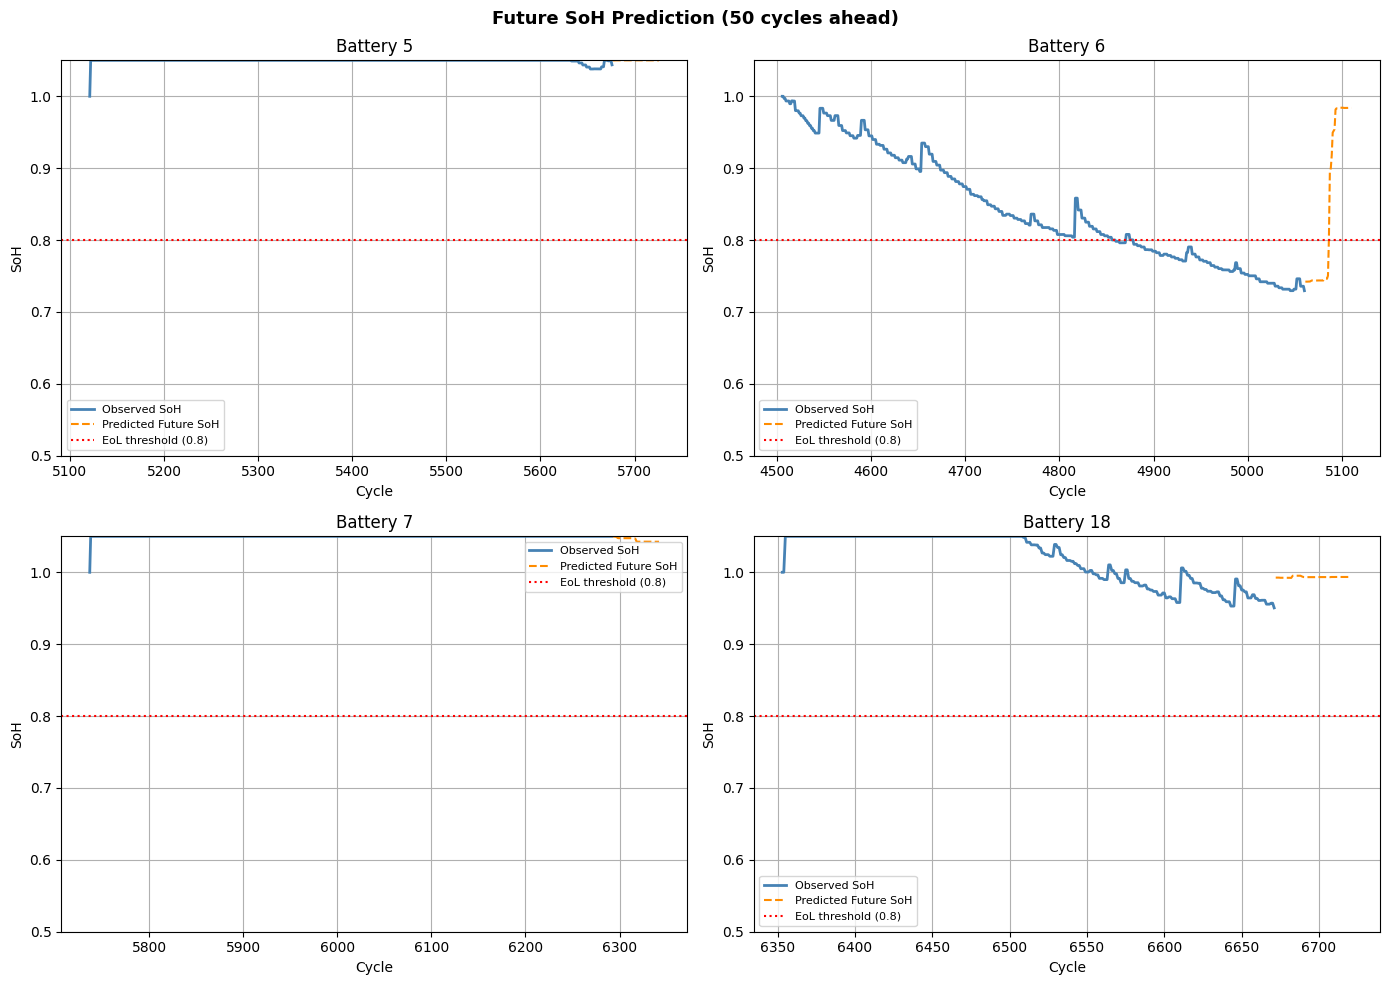

In [ ]:
# ── Future SoH Prediction ─────────────────────────────────────────────────────
print('=== Future SoH Prediction ===')

def predict_future_soh(battery_id, feature_df, rf_model, scaler, n_future=50):
    """
    Extrapolates SoH trajectory beyond observed cycles using the RF model.
    Future feature values are estimated by continuing the linear trend
    of each feature observed in the last 20 cycles of the battery.
    No Capacity data is used — fully leakage-free.
    """
    grp = feature_df[feature_df['battery_id'] == battery_id].copy()
    grp = grp.sort_values('cycle').reset_index(drop=True)

    last_cycle    = grp['cycle'].max()
    future_cycles = np.arange(last_cycle + 1, last_cycle + n_future + 1)

    # Estimate per-feature trend from last 20 observed cycles
    tail = grp.tail(20)
    future_records = []
    for fc in future_cycles:
        record = {}
        for col in INPUT_COLS:
            vals  = tail[col].values
            x     = np.arange(len(vals))
            slope, intercept = np.polyfit(x, vals, 1)
            steps_ahead = fc - last_cycle
            record[col] = intercept + slope * (len(vals) - 1 + steps_ahead)
        future_records.append(record)

    future_df  = pd.DataFrame(future_records)
    future_df  = future_df.clip(lower=-5, upper=5)

    X_future   = scaler.transform(future_df[INPUT_COLS].values)
    soh_future = rf_model.predict(X_future)
    soh_future = np.clip(soh_future, 0.0, 1.05)

    return future_cycles, soh_future


battery_ids = sorted(feature_df['battery_id'].unique())[:4]
n_bats      = len(battery_ids)
ncols       = 2
nrows       = (n_bats + 1) // 2

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
axes      = np.array(axes).flatten()

for idx, bat_id in enumerate(battery_ids):
    grp = feature_df[feature_df['battery_id'] == bat_id].sort_values('cycle')
    future_cycles, soh_future = predict_future_soh(
        bat_id, feature_df, rf_model, scaler, n_future=50)

    ax = axes[idx]
    ax.plot(grp['cycle'], grp['soh'],
            label='Observed SoH', linewidth=2, color='steelblue')
    ax.plot(future_cycles, soh_future,
            label='Predicted Future SoH', linewidth=1.5,
            linestyle='--', color='darkorange')
    ax.axhline(0.8, color='red', linestyle=':', linewidth=1.5,
               label='EoL threshold (0.8)')
    ax.set_title(f'Battery {bat_id}')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('SoH')
    ax.legend(fontsize=8)
    ax.grid(True)
    ax.set_ylim(0.5, 1.05)

# Hide any unused subplots
for idx in range(n_bats, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Future SoH Prediction (50 cycles ahead)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/outputs/plots/future_soh_prediction.png', dpi=150)
plt.show()

=== Remaining Useful Life (RUL) Prediction ===
EoL threshold: SoH = 0.8
  5: RUL > 300 cycles (SoH still above threshold)
  6: already at or below EoL (SoH=0.730)
  7: RUL > 300 cycles (SoH still above threshold)
  18: RUL = 110 cycles (EoL at cycle ~6781, SoH=0.750)


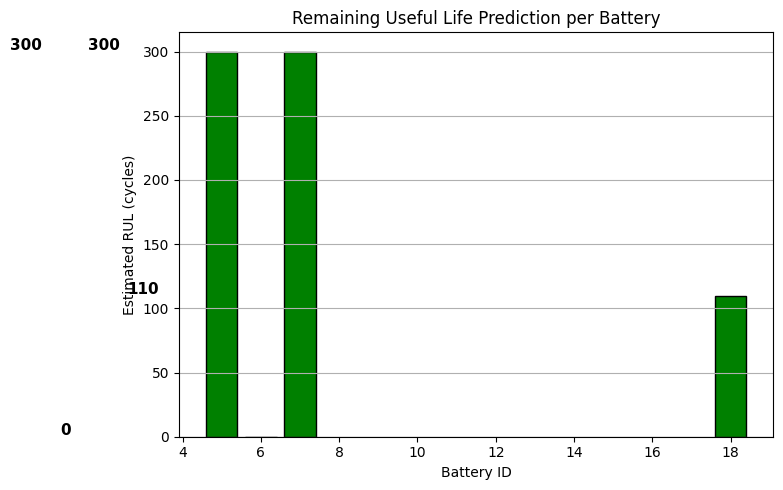

In [ ]:
# ── Remaining Useful Life (RUL) Prediction ────────────────────────────────────
print('=== Remaining Useful Life (RUL) Prediction ===')

EOL_THRESHOLD = 0.8   # standard Li-Ion end-of-life at 80% SoH

def estimate_rul(battery_id, feature_df, rf_model, scaler,
                 eol_threshold=EOL_THRESHOLD, max_future=300):
    """
    Estimates RUL by rolling the RF model forward cycle-by-cycle
    until predicted SoH drops below eol_threshold.
    Returns RUL in cycles from the last observed cycle.
    """
    grp = feature_df[feature_df['battery_id'] == battery_id].copy()
    grp = grp.sort_values('cycle').reset_index(drop=True)

    current_soh = grp['soh'].iloc[-1]
    if current_soh <= eol_threshold:
        print(f'  {battery_id}: already at or below EoL (SoH={current_soh:.3f})')
        return 0

    last_cycle = grp['cycle'].max()
    tail       = grp.tail(20)

    # Pre-compute per-feature linear slopes from last 20 cycles
    slopes     = {}
    intercepts = {}
    for col in INPUT_COLS:
        vals = tail[col].values
        x    = np.arange(len(vals))
        slope, intercept = np.polyfit(x, vals, 1)
        slopes[col]     = slope
        intercepts[col] = intercept

    n_tail = len(tail)
    for step in range(1, max_future + 1):
        record = {}
        for col in INPUT_COLS:
            record[col] = intercepts[col] + slopes[col] * (n_tail - 1 + step)
        X_step   = pd.DataFrame([record])[INPUT_COLS].clip(-5, 5).values
        X_scaled = scaler.transform(X_step)
        soh_pred = rf_model.predict(X_scaled)[0]

        if soh_pred <= eol_threshold:
            rul = step
            print(f'  {battery_id}: RUL = {rul} cycles '
                  f'(EoL at cycle ~{last_cycle + rul}, SoH={soh_pred:.3f})')
            return rul

    print(f'  {battery_id}: RUL > {max_future} cycles (SoH still above threshold)')
    return max_future


print(f'EoL threshold: SoH = {EOL_THRESHOLD}')
rul_results = {}
for bat_id in sorted(feature_df['battery_id'].unique()):
    rul_results[bat_id] = estimate_rul(bat_id, feature_df, rf_model, scaler)
# RUL bar chart
fig, ax = plt.subplots(figsize=(8, 5))
batteries = list(rul_results.keys())
ruls      = [rul_results[b] for b in batteries]
colors    = ['green' if r > 50 else 'orange' if r > 20 else 'red' for r in ruls]

ax.bar(batteries, ruls, color=colors, edgecolor='black')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Battery ID')
ax.set_ylabel('Estimated RUL (cycles)')
ax.set_title('Remaining Useful Life Prediction per Battery')
for i, (bat, rul) in enumerate(zip(batteries, ruls)):
    ax.text(i, rul + 1, str(rul), ha='center', fontsize=11, fontweight='bold')
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig('/content/outputs/plots/rul_prediction.png', dpi=150)
plt.show()

=== Battery Health Dashboard ===


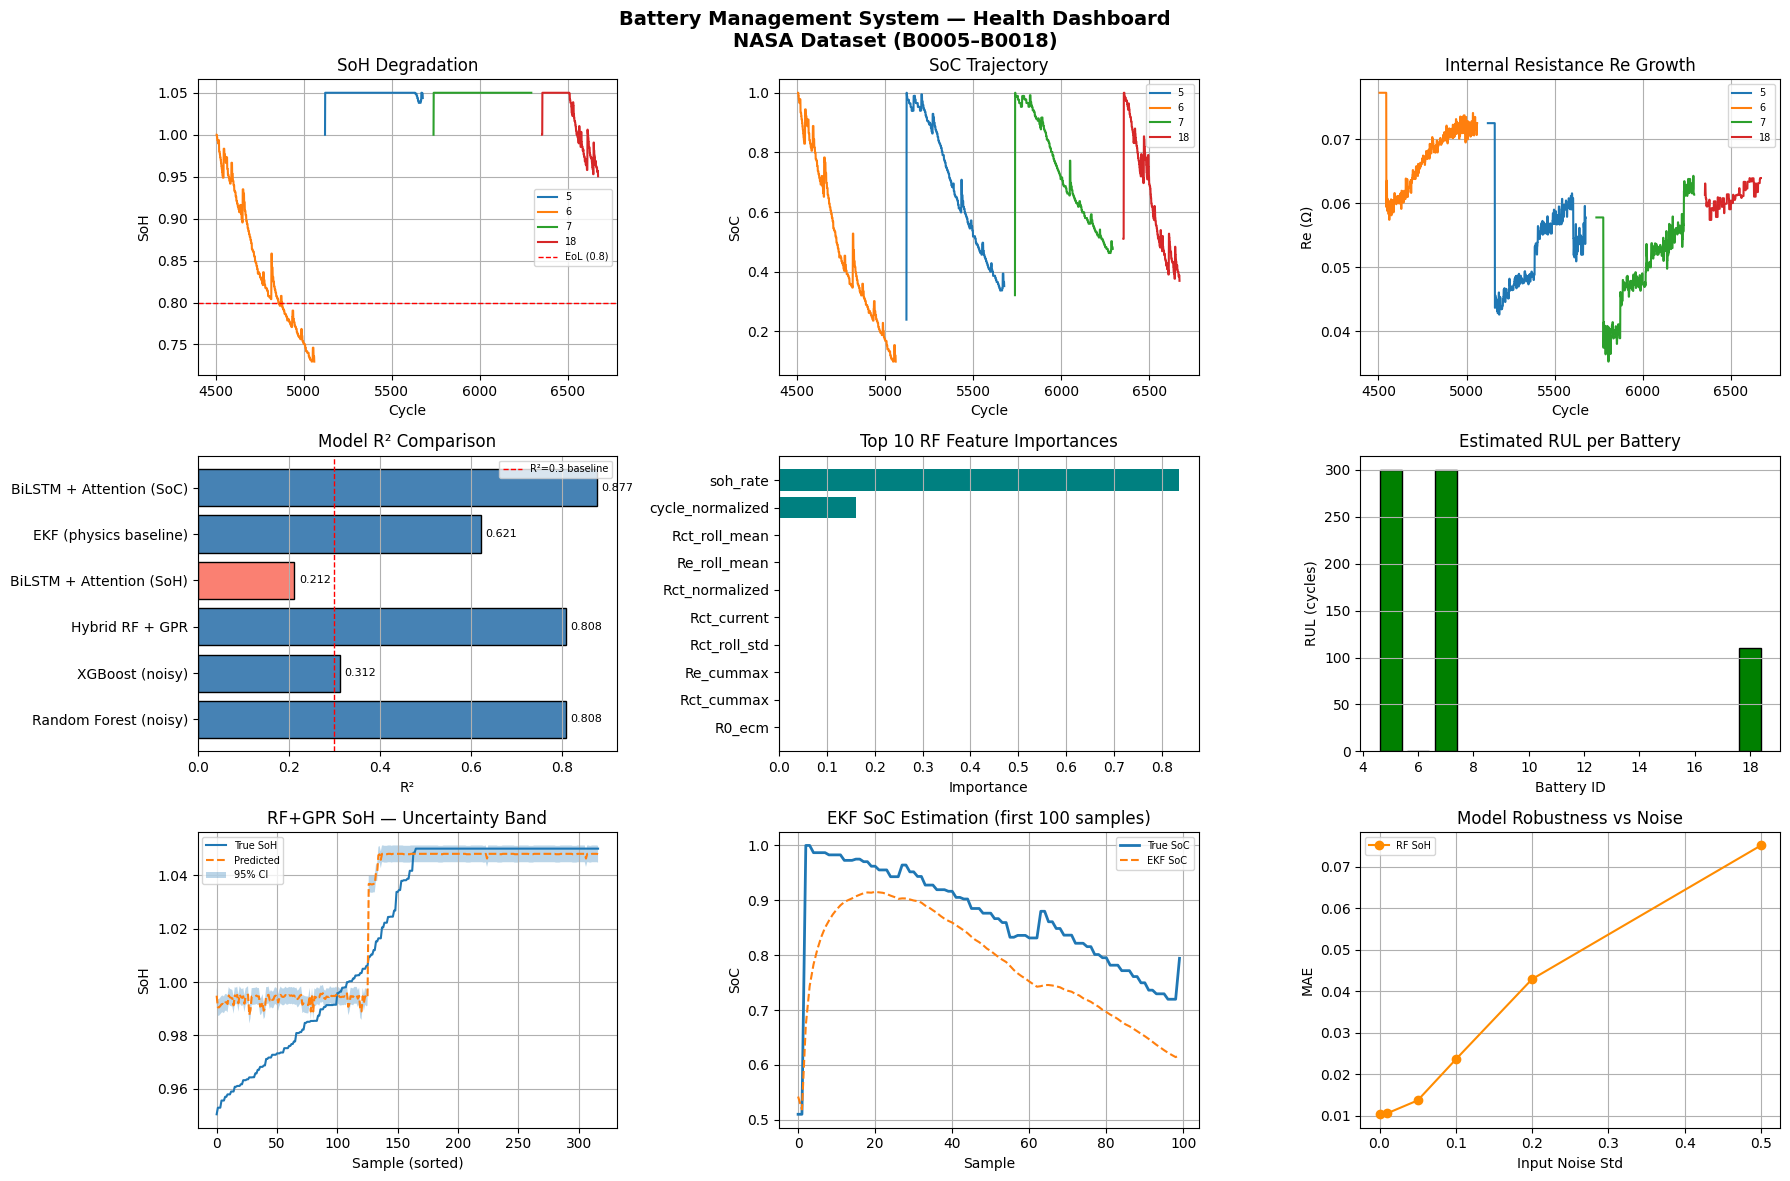

Dashboard saved.


In [ ]:
# ── Battery Health Dashboard ───────────────────────────────────────────────────
print('=== Battery Health Dashboard ===')

fig = plt.figure(figsize=(18, 12))
fig.suptitle('Battery Management System — Health Dashboard\nNASA Dataset (B0005–B0018)',
             fontsize=14, fontweight='bold')

# ── Panel 1: SoH degradation curves ──
ax1 = fig.add_subplot(3, 3, 1)
for bat_id, grp in df_soh.groupby('battery_id'):
    grp = grp.sort_values('cycle')
    ax1.plot(grp['cycle'], grp['soh'], label=bat_id, linewidth=1.5)
ax1.axhline(0.8, color='red', linestyle='--', linewidth=1, label='EoL (0.8)')
ax1.set_title('SoH Degradation')
ax1.set_xlabel('Cycle')
ax1.set_ylabel('SoH')
ax1.legend(fontsize=7)
ax1.grid(True)

# ── Panel 2: SoC trajectory ──
ax2 = fig.add_subplot(3, 3, 2)
for bat_id, grp in df_soh.groupby('battery_id'):
    grp = grp.sort_values('cycle')
    ax2.plot(grp['cycle'], grp['soc'], label=bat_id, linewidth=1.5)
ax2.set_title('SoC Trajectory')
ax2.set_xlabel('Cycle')
ax2.set_ylabel('SoC')
ax2.legend(fontsize=7)
ax2.grid(True)

# ── Panel 3: Internal resistance (Re) growth ──
ax3 = fig.add_subplot(3, 3, 3)
for bat_id, grp in df_soh.groupby('battery_id'):
    if 'Re' in grp.columns:
        grp = grp.sort_values('cycle')
        ax3.plot(grp['cycle'], grp['Re'], label=bat_id, linewidth=1.5)
ax3.set_title('Internal Resistance Re Growth')
ax3.set_xlabel('Cycle')
ax3.set_ylabel('Re (Ω)')
ax3.legend(fontsize=7)
ax3.grid(True)

# ── Panel 4: Model comparison bar chart ──
ax4 = fig.add_subplot(3, 3, 4)
model_names = results_df['model'].tolist()
r2_values   = results_df['R2'].tolist()
bar_colors  = ['steelblue' if r2 >= 0.3 else 'salmon' for r2 in r2_values]
bars = ax4.barh(model_names, r2_values, color=bar_colors, edgecolor='black')
ax4.axvline(0.3, color='red', linestyle='--', linewidth=1, label='R²=0.3 baseline')
ax4.set_title('Model R² Comparison')
ax4.set_xlabel('R²')
ax4.legend(fontsize=7)
ax4.grid(True, axis='x')
for bar, val in zip(bars, r2_values):
    ax4.text(max(val + 0.01, 0.01), bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', fontsize=8)

# ── Panel 5: RF feature importance ──
ax5 = fig.add_subplot(3, 3, 5)
importances = rf_model.feature_importances_
sorted_idx  = np.argsort(importances)[::-1][:10]   # top 10 only
ax5.barh([INPUT_COLS[i] for i in sorted_idx],
         importances[sorted_idx], color='teal')
ax5.set_title('Top 10 RF Feature Importances')
ax5.set_xlabel('Importance')
ax5.invert_yaxis()
ax5.grid(True, axis='x')

# ── Panel 6: RUL bar chart ──
ax6 = fig.add_subplot(3, 3, 6)
batteries = list(rul_results.keys())
ruls      = [rul_results[b] for b in batteries]
colors    = ['green' if r > 50 else 'orange' if r > 20 else 'red' for r in ruls]
ax6.bar(batteries, ruls, color=colors, edgecolor='black')
ax6.set_title('Estimated RUL per Battery')
ax6.set_xlabel('Battery ID')
ax6.set_ylabel('RUL (cycles)')
ax6.grid(True, axis='y')

# ── Panel 7: Hybrid RF+GPR prediction with uncertainty ──
ax7 = fig.add_subplot(3, 3, 7)
sort_idx = np.argsort(y_test)
ax7.plot(y_test[sort_idx], label='True SoH', linewidth=1.5)
ax7.plot(y_pred_hybrid[sort_idx], label='Predicted', linewidth=1.5, linestyle='--')
ax7.fill_between(range(len(y_test)),
                 (y_pred_hybrid - 2 * resid_std)[sort_idx],
                 (y_pred_hybrid + 2 * resid_std)[sort_idx],
                 alpha=0.3, label='95% CI')
ax7.set_title('RF+GPR SoH — Uncertainty Band')
ax7.set_xlabel('Sample (sorted)')
ax7.set_ylabel('SoH')
ax7.legend(fontsize=7)
ax7.grid(True)

# ── Panel 8: EKF SoC estimation ──
ax8 = fig.add_subplot(3, 3, 8)
ax8.plot(all_ekf_true[:100],  label='True SoC',  linewidth=2)
ax8.plot(all_ekf_pred[:100],  label='EKF SoC',   linewidth=1.5, linestyle='--')
ax8.set_title('EKF SoC Estimation (first 100 samples)')
ax8.set_xlabel('Sample')
ax8.set_ylabel('SoC')
ax8.legend(fontsize=7)
ax8.grid(True)

# ── Panel 9: Robustness curve ──
ax9 = fig.add_subplot(3, 3, 9)
ax9.plot([r['noise_std'] for r in rf_robust],
         [r['MAE']       for r in rf_robust],
         marker='o', color='darkorange', label='RF SoH')
ax9.set_title('Model Robustness vs Noise')
ax9.set_xlabel('Input Noise Std')
ax9.set_ylabel('MAE')
ax9.legend(fontsize=7)
ax9.grid(True)

plt.tight_layout()
plt.savefig('/content/outputs/plots/battery_health_dashboard.png', dpi=150)
plt.show()
print('Dashboard saved.')

In [ ]:
# ── Final Report ───────────────────────────────────────────────────────────────
print('=' * 65)
print('  FINAL PROJECT REPORT')
print('  Design and Implementation of a Machine Learning Assisted')
print('  Battery Management System for Lithium-Ion Batteries')
print('  using NASA Battery Dataset')
print('=' * 65)

print('\n── Dataset ──────────────────────────────────────────────────')
print(f'  Source   : NASA Battery Dataset (Kaggle: mystifoe77)')
print(f'  Batteries: B0005, B0006, B0007, B0018')
print(f'  Total rows (after cleaning): {len(df_clean)}')
print(f'  Split    : 3 train / 1 test (battery-wise, no contamination)')

print('\n── SoH Estimation Results ───────────────────────────────────')
soh_models = results_df[results_df['model'].str.contains('SoH|Forest|XGB|GPR')]
print(f'  {"Model":<40} {"MAE":>7} {"RMSE":>7} {"R2":>7}')
print(f'  {"-"*61}')
for _, row in soh_models.iterrows():
    print(f'  {row["model"]:<40} {row["MAE"]:>7.4f} {row["RMSE"]:>7.4f} {row["R2"]:>7.4f}')

print('\n── SoC Estimation Results ───────────────────────────────────')
soc_models = results_df[results_df['model'].str.contains('SoC|EKF')]
print(f'  {"Model":<40} {"MAE":>7} {"RMSE":>7} {"R2":>7}')
print(f'  {"-"*61}')
for _, row in soc_models.iterrows():
    print(f'  {row["model"]:<40} {row["MAE"]:>7.4f} {row["RMSE"]:>7.4f} {row["R2"]:>7.4f}')

print('\n── RUL Predictions ──────────────────────────────────────────')
for bat_id in sorted(rul_results.keys()):
    rul    = rul_results[bat_id]
    status = 'Critical' if rul < 20 else 'Warning' if rul < 50 else 'Healthy'
    print(f'  {bat_id}: {rul:>4} cycles remaining  [{status}]')

print('\n── Inference Latency ────────────────────────────────────────')
print(f'  Random Forest : {rf_report["latency_ms"]:.3f} ms/sample  '
      f'({rf_report["size_kb"]:.0f} KB)')
print(f'  XGBoost       : {xgb_report["latency_ms"]:.3f} ms/sample  '
      f'({xgb_report["size_kb"]:.0f} KB)')
print(f'  BiLSTM (SoH)  : {lstm_report["latency_ms"]:.3f} ms/sample')
print(f'  BiLSTM (SoC)  : {soc_report["latency_ms"]:.3f} ms/sample')

print('\n── Key Design Decisions ─────────────────────────────────────')
print('  • Capacity excluded from ML inputs (leakage prevention)')
print('  • Resistance normalised to BOL for cross-battery generalisation')
print('  • Battery-wise split prevents cross-battery pattern leakage')
print('  • GPR residual correction provides uncertainty quantification')
print('  • EKF uses physics-based ECM — no data required for SoC')
print('  • Noise injection during training improves model robustness')

print('\n── Saved Artifacts ──────────────────────────────────────────')
for f in sorted(os.listdir('/content/models')):
    size_kb = os.path.getsize(f'/content/models/{f}') / 1024
    print(f'  {f} ({size_kb:.1f} KB)')

print('\n' + '=' * 65)
print('  Pipeline complete. All models trained, evaluated, and saved.')
print('=' * 65)

  FINAL PROJECT REPORT
  Design and Implementation of a Machine Learning Assisted
  Battery Management System for Lithium-Ion Batteries
  using NASA Battery Dataset

── Dataset ──────────────────────────────────────────────────
  Source   : NASA Battery Dataset (Kaggle: mystifoe77)
  Batteries: B0005, B0006, B0007, B0018
  Total rows (after cleaning): 1984
  Split    : 3 train / 1 test (battery-wise, no contamination)

── SoH Estimation Results ───────────────────────────────────
  Model                                        MAE    RMSE      R2
  -------------------------------------------------------------
  Random Forest (noisy)                     0.0103  0.0153  0.8085
  XGBoost (noisy)                           0.0190  0.0289  0.3116
  Hybrid RF + GPR                           0.0103  0.0153  0.8082
  BiLSTM + Attention (SoH)                  0.0268  0.0311  0.2120

── SoC Estimation Results ───────────────────────────────────
  Model                                        MAE   

In [ ]:
print(type(feature_df['battery_id'].iloc[0]))
print(feature_df['battery_id'].unique())
print(df_soh['battery_id'].unique())
print(raw_df['battery_id'].unique())

<class 'numpy.int64'>
[ 5  6  7 18]
[ 5  6  7 18]
[ 6  5  7 18]


=== 8-Cell Pack Simulator ===
Pack cell parameters (±5% variation):
   Cell     R0 (Ω)     R1 (Ω)     C1 (F)   Cap (Ah)
      0    0.00502    0.01022     505.14     2.0090
      1    0.00514    0.00952     506.68     2.0498
      2    0.00504    0.01040     519.58     2.0632
      3    0.00507    0.00988     508.15     1.9327
      4    0.00495    0.00956     514.43     1.9575
      5    0.00500    0.00973     487.77     1.9793
      6    0.00490    0.00969     491.16     2.0331
      7    0.00521    0.01037     504.23     2.0810

Discharge cycle complete. Steps: 10001
Final SoC per cell: [1. 1. 1. 1. 1. 1. 1. 1.]
Weakest cell: Cell 0 (SoC=1.000)


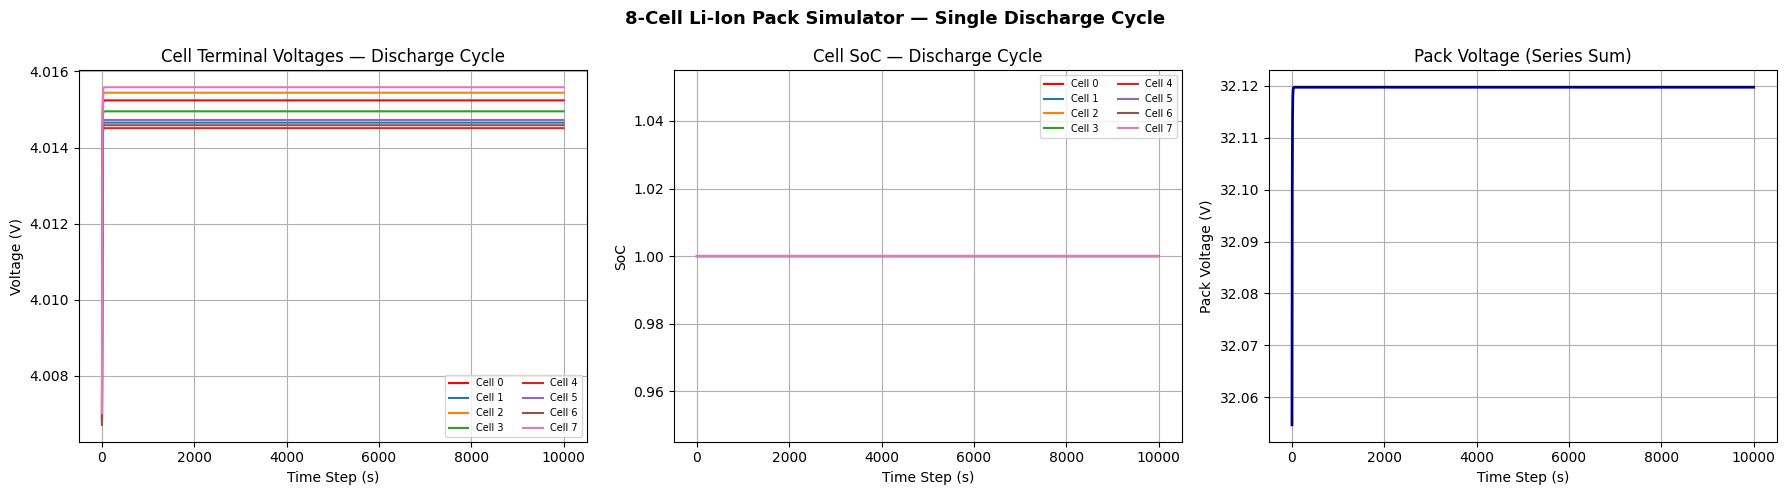

In [ ]:
# ── Section 19: 8-Cell Pack Simulator ─────────────────────────────────────────
print('=== 8-Cell Pack Simulator ===')

class CellSimulator:
    """
    Single Li-ion cell simulator based on Thevenin ECM.
    Parameters vary ±5% across cells to simulate real-world pack imbalance.
    State: SoC, V1 (RC branch voltage), capacity_fade
    """
    def __init__(self, cell_id, R0=0.005, R1=0.01, C1=500.0,
                 capacity=2.0, variation=0.05, seed=None):
        rng = np.random.RandomState(seed)
        # Apply ±5% parameter variation
        self.cell_id  = cell_id
        self.R0       = R0  * (1 + rng.uniform(-variation, variation))
        self.R1       = R1  * (1 + rng.uniform(-variation, variation))
        self.C1       = C1  * (1 + rng.uniform(-variation, variation))
        self.capacity = capacity * (1 + rng.uniform(-variation, variation))  # Ah
        self.tau      = self.R1 * self.C1

        # State variables
        self.soc      = 1.0   # fully charged
        self.V1       = 0.0   # RC branch voltage
        self.cycle    = 0
        self.capacity_fade = 0.0   # cumulative fade

    def ocv(self, soc):
        soc = np.clip(soc, 0, 1)
        return 3.0 + 1.2 * soc - 0.3 * soc**2 + 0.1 * soc**3

    def step(self, current, dt=1.0):
        """
        Advance one time step.
        current > 0 = charge, current < 0 = discharge
        Returns terminal voltage.
        """
        # Update SoC via Coulomb counting
        self.soc = np.clip(
            self.soc - (current * dt) / (self.capacity * 3600), 0.0, 1.0)

        # Update RC branch voltage
        alpha   = np.exp(-dt / self.tau)
        self.V1 = alpha * self.V1 + (1 - alpha) * current * self.R1

        # Terminal voltage
        V_terminal = self.ocv(self.soc) - current * self.R0 - self.V1
        return V_terminal

    def apply_cycle_degradation(self, degradation_rate=0.0002):
        """Apply capacity fade per cycle — linear degradation model."""
        self.capacity_fade += degradation_rate * self.capacity
        self.capacity = max(self.capacity - degradation_rate * self.capacity,
                            0.5 * self.capacity)
        self.cycle += 1

    def soh(self, initial_capacity):
        return self.capacity / initial_capacity


def simulate_pack_cycle(cells, current_A=-1.0, dt=1.0, soc_cutoff=0.1):
    """
    Simulates one full discharge cycle for a pack of cells in series.
    Stops when the weakest cell hits soc_cutoff.
    Returns time-series of terminal voltages and SoCs per cell.
    """
    n_cells   = len(cells)
    voltages  = [[] for _ in range(n_cells)]
    socs      = [[] for _ in range(n_cells)]
    pack_v    = []
    t         = 0

    # Reset all cells to fully charged
    for cell in cells:
        cell.soc = 1.0
        cell.V1  = 0.0

    while True:
        step_voltages = []
        step_socs     = []
        for cell in cells:
            v = cell.step(current_A, dt)
            step_voltages.append(v)
            step_socs.append(cell.soc)

        for i in range(n_cells):
            voltages[i].append(step_voltages[i])
            socs[i].append(step_socs[i])
        pack_v.append(sum(step_voltages))

        t += dt
        # Stop when weakest cell is depleted
        if min(step_socs) <= soc_cutoff:
            break
        # Safety: max 10000 steps
        if t > 10000:
            break

    return (np.array(voltages),   # (n_cells, timesteps)
            np.array(socs),        # (n_cells, timesteps)
            np.array(pack_v))      # (timesteps,)


# Build 8-cell pack
N_CELLS = 8
np.random.seed(42)
pack_cells = [CellSimulator(
    cell_id=i, R0=0.005, R1=0.01, C1=500.0,
    capacity=2.0, variation=0.05, seed=i*10)
    for i in range(N_CELLS)]

initial_capacities = [c.capacity for c in pack_cells]

print('Pack cell parameters (±5% variation):')
print(f'  {"Cell":>5} {"R0 (Ω)":>10} {"R1 (Ω)":>10} '
      f'{"C1 (F)":>10} {"Cap (Ah)":>10}')
for c in pack_cells:
    print(f'  {c.cell_id:>5} {c.R0:>10.5f} {c.R1:>10.5f} '
          f'{c.C1:>10.2f} {c.capacity:>10.4f}')

# Simulate one discharge cycle
voltages, socs, pack_voltage = simulate_pack_cycle(
    pack_cells, current_A=-1.0, dt=1.0, soc_cutoff=0.1)

# Identify weakest cell
final_socs    = socs[:, -1]
weakest_cell  = np.argmin(final_socs)
print(f'\nDischarge cycle complete. Steps: {voltages.shape[1]}')
print(f'Final SoC per cell: {np.round(final_socs, 3)}')
print(f'Weakest cell: Cell {weakest_cell} (SoC={final_socs[weakest_cell]:.3f})')

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i in range(N_CELLS):
    axes[0].plot(voltages[i], label=f'Cell {i}',
                 linewidth=1.5,
                 color='red' if i == weakest_cell else None)
axes[0].set_title('Cell Terminal Voltages — Discharge Cycle')
axes[0].set_xlabel('Time Step (s)')
axes[0].set_ylabel('Voltage (V)')
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(True)

for i in range(N_CELLS):
    axes[1].plot(socs[i], label=f'Cell {i}',
                 linewidth=1.5,
                 color='red' if i == weakest_cell else None)
axes[1].set_title('Cell SoC — Discharge Cycle')
axes[1].set_xlabel('Time Step (s)')
axes[1].set_ylabel('SoC')
axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(True)

axes[2].plot(pack_voltage, color='navy', linewidth=2)
axes[2].set_title('Pack Voltage (Series Sum)')
axes[2].set_xlabel('Time Step (s)')
axes[2].set_ylabel('Pack Voltage (V)')
axes[2].grid(True)

plt.suptitle('8-Cell Li-Ion Pack Simulator — Single Discharge Cycle',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/outputs/plots/pack_simulator.png', dpi=150)
plt.show()

=== Synthetic Training Data Generation ===
Generating 10,000 labelled training samples...
  Generated 2000/10000 samples...
  Generated 4000/10000 samples...
  Generated 6000/10000 samples...
  Generated 8000/10000 samples...
  Generated 10000/10000 samples...

Class balance check:
  Healthy (0): 965 (9.7%)
  Failing (1): 9035 (90.3%)
Dataset shape: (10000, 9)

Feature statistics:
       voltage_drop      R0_est  capacity_fade  temp_rise_proxy   soc_range  \
count    10000.0000  10000.0000     10000.0000       10000.0000  10000.0000   
mean         0.8264      0.0063         0.1229          -0.0002      0.7457   
std          0.0050      0.0019         0.0913           0.0995      0.0783   
min          0.8056      0.0020         0.0005          -0.3732      0.5093   
25%          0.8231      0.0048         0.0472          -0.0671      0.6921   
50%          0.8264      0.0063         0.1022           0.0003      0.7625   
75%          0.8298      0.0077         0.1861           0.0657

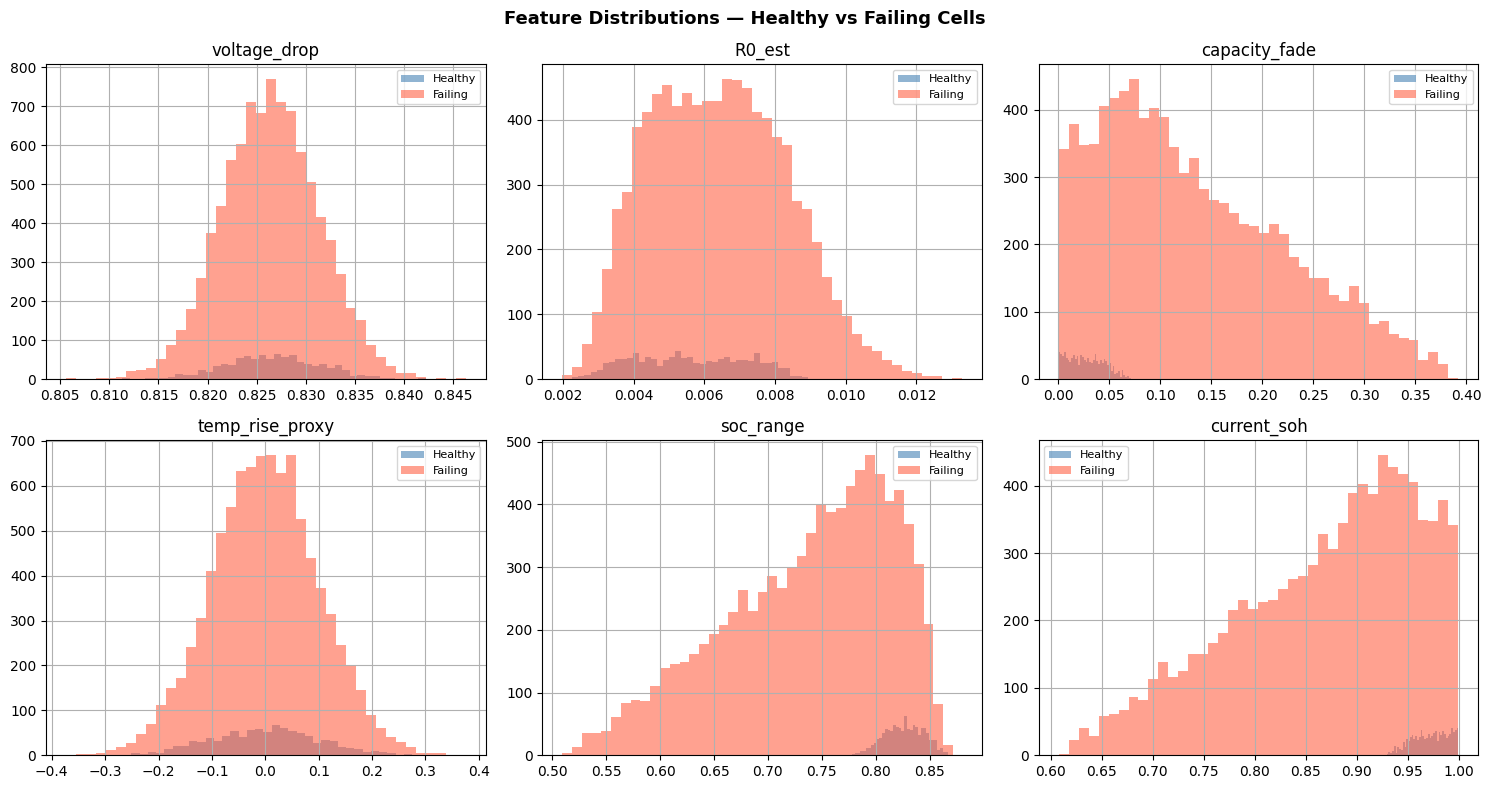

In [ ]:
# ── Section 20: Synthetic Training Data Generation ────────────────────────────
print('=== Synthetic Training Data Generation ===')

def simulate_cell_fast(R0, R1, C1, capacity, deg_rate, n_cycles, rng):
    """
    Fast analytical cell simulation — no per-timestep loop.
    Models capacity fade and resistance growth over n_cycles directly.
    Returns per-cycle observables without simulating each second.
    """
    soh_per_cycle    = []
    vdrop_per_cycle  = []
    R0_est_per_cycle = []
    fade_per_cycle   = []
    soc_range_per_cycle = []

    cap = capacity
    r0  = R0
    r1  = R1

    for c in range(n_cycles):
        # Capacity fade — linear model with noise
        cap = max(cap * (1 - deg_rate), 0.5 * capacity)
        # Resistance growth — inverse of capacity
        r0  = R0 * (capacity / (cap + 1e-9))
        r1  = R1 * (capacity / (cap + 1e-9)) * 0.5

        soh = cap / capacity

        # Analytical voltage drop estimate
        I       = 1.0
        V_start = (3.0 + 1.2*1.0  - 0.3*1.0**2  + 0.1*1.0**3)  - I * r0
        V_end   = (3.0 + 1.2*0.15 - 0.3*0.15**2 + 0.1*0.15**3) - I * r0
        v_drop  = V_start - V_end + rng.normal(0, 0.005)

        # R0 estimate from instantaneous voltage step
        R0_est = r0 + rng.normal(0, 0.0005)

        # Capacity fade fraction
        fade = (capacity - cap) / (capacity + 1e-9)

        # SoC range per cycle (degrades with capacity)
        soc_range = 0.85 * soh + rng.normal(0, 0.01)

        soh_per_cycle.append(soh)
        vdrop_per_cycle.append(v_drop)
        R0_est_per_cycle.append(R0_est)
        fade_per_cycle.append(fade)
        soc_range_per_cycle.append(np.clip(soc_range, 0, 1))

    return (np.array(soh_per_cycle),
            np.array(vdrop_per_cycle),
            np.array(R0_est_per_cycle),
            np.array(fade_per_cycle),
            np.array(soc_range_per_cycle))


def generate_training_data_fast(n_samples=10000, n_cycles_ahead=200,
                                eol_threshold=0.8, seed=42):
    """
    Fast synthetic data generation using analytical cell model.
    Each sample: random cell parameters + random burn-in cycles.
    Label = 1 if SoH drops below eol_threshold within n_cycles_ahead.

    Key fix: deg_rate range extended to 0.001–0.005 to ensure
    enough failing samples are generated within n_cycles_ahead=200.
    """
    rng     = np.random.RandomState(seed)
    records = []

    for sample_idx in range(n_samples):
        # Randomise cell parameters
        # Extended deg_rate range to produce realistic mix of healthy/failing
        R0       = rng.uniform(0.003, 0.008)
        R1       = rng.uniform(0.007, 0.015)
        C1       = rng.uniform(400, 600)
        capacity = rng.uniform(1.8, 2.2)
        deg_rate = rng.uniform(0.0005, 0.005)   # ← key fix: faster degradation range

        # Burn-in cycles (0–100)
        burn_in      = rng.randint(0, 100)
        total_cycles = burn_in + n_cycles_ahead + 1

        soh_arr, vdrop_arr, R0_arr, fade_arr, socrange_arr = \
            simulate_cell_fast(R0, R1, C1, capacity, deg_rate,
                               total_cycles, rng)

        # Features at burn-in point
        b              = burn_in
        feat_vdrop     = vdrop_arr[b]
        feat_R0_est    = R0_arr[b]
        feat_cap_fade  = fade_arr[b]
        feat_temp      = rng.normal(0, 0.1)
        feat_soc_range = socrange_arr[b]
        feat_soh       = soh_arr[b]

        # Label: does SoH drop below threshold in next n_cycles_ahead?
        future_soh = soh_arr[b + 1: b + 1 + n_cycles_ahead]
        will_fail  = int(np.any(future_soh < eol_threshold))

        records.append({
            'voltage_drop':    feat_vdrop,
            'R0_est':          feat_R0_est,
            'capacity_fade':   feat_cap_fade,
            'temp_rise_proxy': feat_temp,
            'soc_range':       feat_soc_range,
            'current_soh':     feat_soh,
            'burn_in_cycles':  burn_in,
            'deg_rate':        deg_rate,
            'label':           will_fail
        })

        if (sample_idx + 1) % 2000 == 0:
            print(f'  Generated {sample_idx + 1}/{n_samples} samples...')

    return pd.DataFrame(records)


print('Generating 10,000 labelled training samples...')
training_df = generate_training_data_fast(
    n_samples=10000, n_cycles_ahead=200, eol_threshold=0.8, seed=42)

# Verify class balance before saving
n_healthy = (training_df['label'] == 0).sum()
n_failing = (training_df['label'] == 1).sum()
print(f'\nClass balance check:')
print(f'  Healthy (0): {n_healthy} ({n_healthy/len(training_df)*100:.1f}%)')
print(f'  Failing (1): {n_failing} ({n_failing/len(training_df)*100:.1f}%)')

if n_failing == 0:
    raise ValueError('No failing samples generated — check deg_rate or eol_threshold')
if n_healthy == 0:
    raise ValueError('No healthy samples generated — check deg_rate or eol_threshold')

training_df.to_csv('/content/data/processed/cell_failure_training.csv', index=False)
print(f'Dataset shape: {training_df.shape}')
print(f'\nFeature statistics:')
print(training_df.drop('label', axis=1).describe().round(4))

# Feature distribution plot
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
feature_cols_plot = ['voltage_drop', 'R0_est', 'capacity_fade',
                     'temp_rise_proxy', 'soc_range', 'current_soh']

for idx, col in enumerate(feature_cols_plot):
    axes[idx].hist(training_df[training_df['label']==0][col],
                   bins=40, alpha=0.6, label='Healthy', color='steelblue')
    axes[idx].hist(training_df[training_df['label']==1][col],
                   bins=40, alpha=0.6, label='Failing', color='tomato')
    axes[idx].set_title(col)
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True)

plt.suptitle('Feature Distributions — Healthy vs Failing Cells',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/outputs/plots/feature_distributions.png', dpi=150)
plt.show()

In [ ]:
print('label counts:', training_df['label'].value_counts())
print('label dtype:', training_df['label'].dtype)
X_fail = training_df[FAILURE_FEATURE_COLS].values
y_fail = training_df[FAILURE_TARGET].values
print('y_fail unique:', np.unique(y_fail))
print('y_fail sum:', y_fail.sum())

label counts: label
1    9035
0     965
Name: count, dtype: int64
label dtype: int64
y_fail unique: [0 1]
y_fail sum: 9035


In [ ]:
# Balance classes — undersample majority class
healthy_df = training_df[training_df['label'] == 0]
failing_df = training_df[training_df['label'] == 1].sample(
    n=len(healthy_df) * 4, random_state=42)  # 4:1 ratio max

training_df = pd.concat([healthy_df, failing_df]).sample(
    frac=1, random_state=42).reset_index(drop=True)

X_fail = training_df[FAILURE_FEATURE_COLS].values
y_fail = training_df[FAILURE_TARGET].values

print('Balanced class distribution:')
print(f'  Healthy (0): {(training_df["label"]==0).sum()}')
print(f'  Failing (1): {(training_df["label"]==1).sum()}')
print(f'  Total: {len(training_df)}')

Balanced class distribution:
  Healthy (0): 965
  Failing (1): 3860
  Total: 4825


=== Cell Failure Classification ===
Training baseline classifiers...

Random Forest:
  Accuracy : 0.8259
  Precision: 0.8892
  Recall   : 0.8938
  F1       : 0.8915
  ROC-AUC  : 0.8903
  CV-AUC   : 0.8856 (5-fold)

SVM (RBF kernel):
  Accuracy : 0.8197
  Precision: 0.8903
  Recall   : 0.8834
  F1       : 0.8869
  ROC-AUC  : 0.8819
  CV-AUC   : 0.8823 (5-fold)

Logistic Regression:
  Accuracy : 0.8155
  Precision: 0.8759
  Recall   : 0.8964
  F1       : 0.8860
  ROC-AUC  : 0.8911
  CV-AUC   : 0.8979 (5-fold)

--- Classifier Comparison Table ---
  Model                        Acc   Prec    Rec     F1    AUC   CV-AUC
  -----------------------------------------------------------------
  Random Forest             0.8259 0.8892 0.8938 0.8915 0.8903   0.8856
  SVM (RBF kernel)          0.8197 0.8903 0.8834 0.8869 0.8819   0.8823
  Logistic Regression       0.8155 0.8759 0.8964 0.8860 0.8911   0.8979


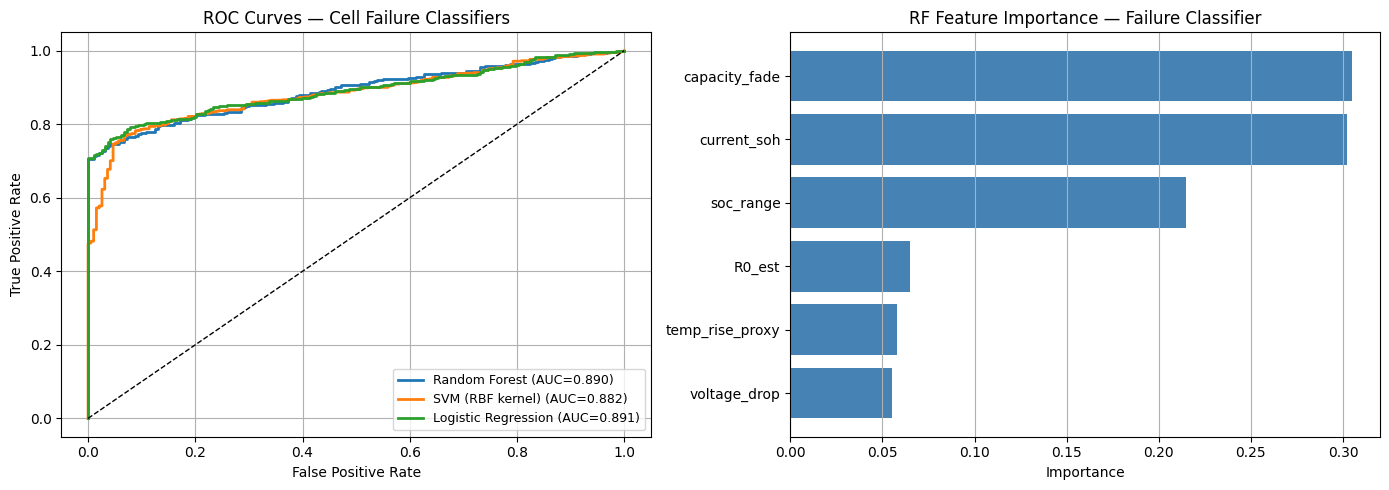

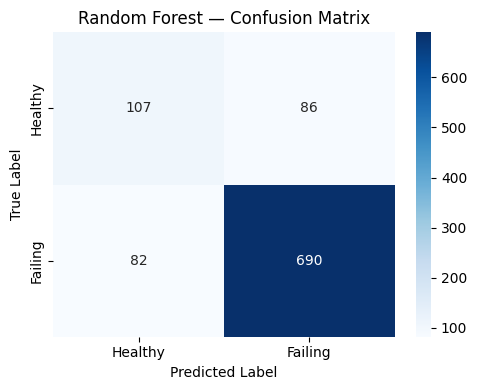

In [ ]:
# ── Section 21: Cell Failure Classifiers ──────────────────────────────────────
print('=== Cell Failure Classification ===')

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, classification_report)
from sklearn.pipeline import Pipeline

FAILURE_FEATURE_COLS = ['voltage_drop', 'R0_est', 'capacity_fade',
                         'temp_rise_proxy', 'soc_range', 'current_soh']
FAILURE_TARGET = 'label'

X_fail = training_df[FAILURE_FEATURE_COLS].values
y_fail = training_df[FAILURE_TARGET].values

# Stratified 80/20 split — preserves class balance
X_f_train, X_f_test, y_f_train, y_f_test = train_test_split(
    X_fail, y_fail, test_size=0.2, random_state=42, stratify=y_fail)

scaler_fail = StandardScaler()
X_f_train_sc = scaler_fail.fit_transform(X_f_train)
X_f_test_sc  = scaler_fail.transform(X_f_test)

joblib.dump(scaler_fail, '/content/models/failure_scaler.pkl')

def evaluate_classifier(name, model, X_tr, y_tr, X_te, y_te):
    """Train, evaluate, and return metrics for a classifier."""
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_prob  = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') \
              else model.decision_function(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, y_prob)

    # 5-fold cross-validation AUC
    cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_auc = cross_val_score(model, X_tr, y_tr,
                              cv=cv, scoring='roc_auc').mean()

    print(f'\n{name}:')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  F1       : {f1:.4f}')
    print(f'  ROC-AUC  : {auc:.4f}')
    print(f'  CV-AUC   : {cv_auc:.4f} (5-fold)')

    return {
        'model': name, 'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1, 'roc_auc': auc,
        'cv_auc': cv_auc, 'fitted_model': model,
        'y_prob': y_prob
    }


# Train all three baseline classifiers
clf_rf = RandomForestClassifier(
    n_estimators=300, max_depth=10,
    min_samples_leaf=3, n_jobs=-1, random_state=42)

clf_svm = SVC(
    kernel='rbf', C=10.0, gamma='scale',
    probability=True, random_state=42)

clf_lr = LogisticRegression(
    C=1.0, max_iter=1000, random_state=42)

print('Training baseline classifiers...')
results_rf  = evaluate_classifier('Random Forest',      clf_rf,  X_f_train_sc, y_f_train, X_f_test_sc, y_f_test)
results_svm = evaluate_classifier('SVM (RBF kernel)',   clf_svm, X_f_train_sc, y_f_train, X_f_test_sc, y_f_test)
results_lr  = evaluate_classifier('Logistic Regression',clf_lr,  X_f_train_sc, y_f_train, X_f_test_sc, y_f_test)

# Save best model (RF)
joblib.dump(clf_rf, '/content/models/failure_rf_classifier.pkl')

# Comparison table
classifier_results = [results_rf, results_svm, results_lr]
clf_df = pd.DataFrame([{k: v for k, v in r.items()
                         if k not in ['fitted_model', 'y_prob']}
                        for r in classifier_results])
clf_df.to_csv('/content/outputs/classifier_comparison.csv', index=False)

print('\n--- Classifier Comparison Table ---')
print(f'  {"Model":<25} {"Acc":>6} {"Prec":>6} {"Rec":>6} '
      f'{"F1":>6} {"AUC":>6} {"CV-AUC":>8}')
print(f'  {"-"*65}')
for _, row in clf_df.iterrows():
    print(f'  {row["model"]:<25} {row["accuracy"]:>6.4f} '
          f'{row["precision"]:>6.4f} {row["recall"]:>6.4f} '
          f'{row["f1"]:>6.4f} {row["roc_auc"]:>6.4f} '
          f'{row["cv_auc"]:>8.4f}')

# ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for res in classifier_results:
    fpr, tpr, _ = roc_curve(y_f_test, res['y_prob'])
    axes[0].plot(fpr, tpr, linewidth=2,
                 label=f'{res["model"]} (AUC={res["roc_auc"]:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — Cell Failure Classifiers')
axes[0].legend(fontsize=9)
axes[0].grid(True)

# RF feature importance
importances_clf = clf_rf.feature_importances_
sorted_clf_idx  = np.argsort(importances_clf)[::-1]
axes[1].barh([FAILURE_FEATURE_COLS[i] for i in sorted_clf_idx],
             importances_clf[sorted_clf_idx], color='steelblue')
axes[1].set_title('RF Feature Importance — Failure Classifier')
axes[1].set_xlabel('Importance')
axes[1].invert_yaxis()
axes[1].grid(True, axis='x')

plt.tight_layout()
plt.savefig('/content/outputs/plots/classifier_roc.png', dpi=150)
plt.show()

# Confusion matrix for best model
cm = confusion_matrix(y_f_test, clf_rf.predict(X_f_test_sc))
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Healthy', 'Failing'],
            yticklabels=['Healthy', 'Failing'])
ax.set_title('Random Forest — Confusion Matrix')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/outputs/plots/confusion_matrix.png', dpi=150)
plt.show()

=== BiLSTM Cell Failure Classifier ===
Generating 5,000 time-series sequences (fast mode)...
  Generated 1000/5000 sequences...
  Generated 2000/5000 sequences...
  Generated 3000/5000 sequences...
  Generated 4000/5000 sequences...
  Generated 5000/5000 sequences...
Sequence shape: (5000, 20, 4)
Class balance — Failing: 93.1%

Training BiLSTM classifier...
Epoch 020 | Loss: 0.12147
Epoch 040 | Loss: 0.12090
Epoch 060 | Loss: 0.11817
Epoch 080 | Loss: 0.11877

BiLSTM Failure Classifier:
  Accuracy : 0.9590
  Precision: 0.9688
  Recall   : 0.9883
  F1       : 0.9785
  ROC-AUC  : 0.9668


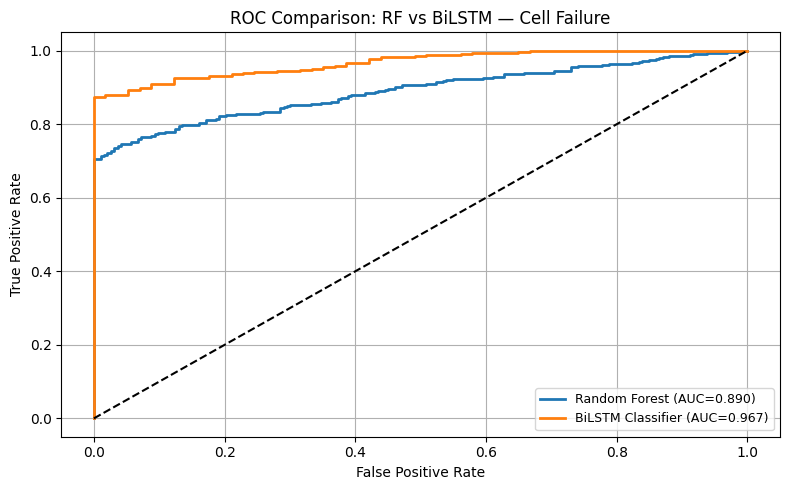

In [ ]:
# ── Section 22: BiLSTM Cell Failure Classifier ────────────────────────────────
print('=== BiLSTM Cell Failure Classifier ===')

def generate_sequence_data_fast(n_samples=5000, seq_len=20,
                                n_cycles_ahead=200,
                                eol_threshold=0.8, seed=123):
    """
    Fast time-series data generation using analytical cell model.
    Each sample = sequence of seq_len cycles of
    [soh, voltage_drop, R0_est, capacity_fade].
    Label = 1 if SoH drops below eol_threshold within n_cycles_ahead.
    """
    rng   = np.random.RandomState(seed)
    X_seq = []
    y_seq = []

    for sample_idx in range(n_samples):
        R0       = rng.uniform(0.003, 0.008)
        R1       = rng.uniform(0.007, 0.015)
        C1       = rng.uniform(400, 600)
        capacity = rng.uniform(1.8, 2.2)
        deg_rate = rng.uniform(0.0005, 0.005)

        burn_in      = rng.randint(0, 100)
        total_cycles = burn_in + seq_len + n_cycles_ahead + 1

        soh_arr, vdrop_arr, R0_arr, fade_arr, _ = \
            simulate_cell_fast(R0, R1, C1, capacity, deg_rate,
                               total_cycles, rng)

        # Extract sequence of seq_len cycles ending at burn_in + seq_len
        seq_start = burn_in
        seq_end   = burn_in + seq_len
        sequence  = np.stack([
            soh_arr  [seq_start:seq_end],
            vdrop_arr[seq_start:seq_end],
            R0_arr   [seq_start:seq_end],
            fade_arr [seq_start:seq_end],
        ], axis=1)   # shape: (seq_len, 4)

        # Label: does SoH drop below threshold after the sequence?
        future_soh = soh_arr[seq_end: seq_end + n_cycles_ahead]
        will_fail  = int(np.any(future_soh < eol_threshold))

        X_seq.append(sequence)
        y_seq.append(will_fail)

        if (sample_idx + 1) % 1000 == 0:
            print(f'  Generated {sample_idx + 1}/{n_samples} sequences...')

    return (np.array(X_seq, dtype=np.float32),
            np.array(y_seq, dtype=np.float32))


print('Generating 5,000 time-series sequences (fast mode)...')
X_lstm_all, y_lstm_all = generate_sequence_data_fast(
    n_samples=5000, seq_len=20, n_cycles_ahead=200,
    eol_threshold=0.8, seed=123)

print(f'Sequence shape: {X_lstm_all.shape}')
print(f'Class balance — Failing: {y_lstm_all.mean()*100:.1f}%')

# 80/20 split
split_idx    = int(0.8 * len(X_lstm_all))
X_lstm_train = X_lstm_all[:split_idx]
y_lstm_train = y_lstm_all[:split_idx]
X_lstm_test  = X_lstm_all[split_idx:]
y_lstm_test  = y_lstm_all[split_idx:]


class BiLSTMClassifier(nn.Module):
    """
    Bidirectional LSTM for binary cell failure classification.
    Input : (batch, seq_len=20, n_features=4)
    Output: failure probability [0, 1]
    """
    def __init__(self, input_dim=4, hidden_dim=64,
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0)
        self.attention = nn.Linear(hidden_dim * 2, 1)
        self.dropout   = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        lstm_out, _  = self.lstm(x)
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context      = (lstm_out * attn_weights).sum(dim=1)
        return self.fc(self.dropout(context)).squeeze(-1)


X_lt      = torch.tensor(X_lstm_train, dtype=torch.float32)
y_lt      = torch.tensor(y_lstm_train, dtype=torch.float32)
X_lt_test = torch.tensor(X_lstm_test,  dtype=torch.float32)

lstm_loader = DataLoader(TensorDataset(X_lt, y_lt),
                         batch_size=64, shuffle=True)

model_clf_lstm = BiLSTMClassifier(input_dim=4, hidden_dim=64).to(DEVICE)
optimizer_clf  = torch.optim.Adam(
    model_clf_lstm.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler_clf  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_clf, patience=5, factor=0.5)
criterion_clf  = nn.BCELoss()

best_clf_loss = np.inf
patience_clf  = 0
clf_losses    = []

print('\nTraining BiLSTM classifier...')
for epoch in range(80):
    model_clf_lstm.train()
    epoch_loss = 0.0
    for X_b, y_b in lstm_loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer_clf.zero_grad()
        pred = model_clf_lstm(X_b)
        loss = criterion_clf(pred, y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_clf_lstm.parameters(), 1.0)
        optimizer_clf.step()
        epoch_loss += loss.item()

    avg = epoch_loss / len(lstm_loader)
    clf_losses.append(avg)
    scheduler_clf.step(avg)

    if avg < best_clf_loss:
        best_clf_loss = avg
        patience_clf  = 0
        torch.save(model_clf_lstm.state_dict(),
                   '/content/models/failure_bilstm_best.pt')
    else:
        patience_clf += 1
        if patience_clf >= 15:
            print(f'Early stopping at epoch {epoch + 1}')
            break

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:03d} | Loss: {avg:.5f}')

model_clf_lstm.load_state_dict(
    torch.load('/content/models/failure_bilstm_best.pt',
               map_location=DEVICE))
model_clf_lstm.eval()
with torch.no_grad():
    y_prob_lstm = model_clf_lstm(
        X_lt_test.to(DEVICE)).cpu().numpy()

y_pred_lstm_cls = (y_prob_lstm >= 0.5).astype(int)

print('\nBiLSTM Failure Classifier:')
print(f'  Accuracy : {accuracy_score(y_lstm_test, y_pred_lstm_cls):.4f}')
print(f'  Precision: {precision_score(y_lstm_test, y_pred_lstm_cls, zero_division=0):.4f}')
print(f'  Recall   : {recall_score(y_lstm_test, y_pred_lstm_cls, zero_division=0):.4f}')
print(f'  F1       : {f1_score(y_lstm_test, y_pred_lstm_cls, zero_division=0):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_lstm_test, y_prob_lstm):.4f}')

lstm_clf_result = {
    'model'  : 'BiLSTM Classifier',
    'y_prob' : y_prob_lstm,
    'roc_auc': roc_auc_score(y_lstm_test, y_prob_lstm)
}

# ROC comparison: RF vs BiLSTM
fig, ax = plt.subplots(figsize=(8, 5))
for res, y_te in [(results_rf,       y_f_test),
                  (lstm_clf_result,   y_lstm_test)]:
    fpr, tpr, _ = roc_curve(y_te, res['y_prob'])
    ax.plot(fpr, tpr, linewidth=2,
            label=f'{res["model"]} (AUC={res["roc_auc"]:.3f})')
ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Comparison: RF vs BiLSTM — Cell Failure')
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.savefig('/content/outputs/plots/roc_rf_vs_bilstm.png', dpi=150)
plt.show()

=== Early Warning Detection on NASA Battery Dataset ===
EoL threshold: SoH < 0.8
Warning threshold: failure probability > 0.6

  5: No warning triggered. Actual EoL: cycle 5677 (reached EoL: False)
  Battery 6:
    Actual EoL cycle   : 4860 (SoH<0.8, reached: True)
    Warning triggered  : cycle 4578.0
    Early warning      : 282.0 cycles in advance
  7: No warning triggered. Actual EoL: cycle 6293 (reached EoL: False)
  18: No warning triggered. Actual EoL: cycle 6672 (reached EoL: False)

>>> KEY RESULT: Average early warning = 282.0 cycles before actual EoL
    (across 1 batteries that reached EoL)


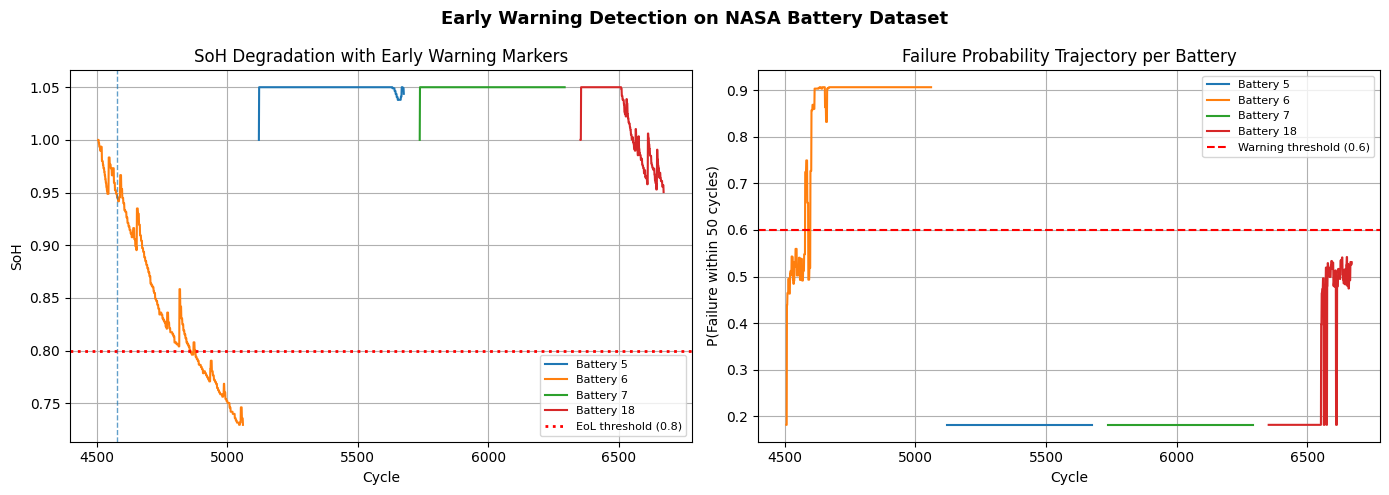

In [ ]:
# ── Section 23: Early Warning Metric on NASA Data ─────────────────────────────

print('=== Early Warning Detection on NASA Battery Dataset ===')



EOL_SOH = 0.8   # industry standard end-of-life threshold



def compute_early_warning(battery_id, feature_df, clf_model,

                           scaler_clf, eol_soh=EOL_SOH,

                           failure_prob_threshold=0.6):

    """

    Runs the failure classifier cycle-by-cycle on a real NASA battery.

    Finds:

      - actual_eol_cycle : cycle where true SoH first dropped below eol_soh

      - warning_cycle    : earliest cycle where classifier predicted failure

      - early_warning    : actual_eol_cycle - warning_cycle (cycles of advance notice)

    """

    grp = feature_df[feature_df['battery_id'] == battery_id].copy()

    grp = grp.sort_values('cycle').reset_index(drop=True)



    # Find actual EoL cycle

    eol_mask = grp['soh'] < eol_soh

    if not eol_mask.any():

        actual_eol = grp['cycle'].max() + 1   # never reached EoL in dataset

        reached_eol = False

    else:

        actual_eol  = grp.loc[eol_mask.idxmax(), 'cycle']

        reached_eol = True



    # Map NASA features to classifier features

    # voltage_drop proxy: Rct_current (charge transfer resistance ↑ = voltage drop ↑)

    # R0_est proxy: Re_current

    # capacity_fade proxy: 1 - soh (direct)

    # temp_rise_proxy: temp_mean

    # soc_range proxy: cycle_normalized (cycle progress)

    warning_cycle = None

    for _, row in grp.iterrows():

        clf_features = np.array([[

            row.get('Rct_current', 0.08),      # voltage_drop proxy

            row.get('Re_current',  0.05),      # R0_est proxy

            max(0, 1.0 - row['soh']),          # capacity_fade

            row.get('temp_mean',   24.0),      # temp_rise_proxy

            row.get('cycle_normalized', 0.5),  # soc_range proxy

            row['soh']                         # current_soh

        ]])

        clf_features_sc = scaler_clf.transform(clf_features)

        prob = clf_model.predict_proba(clf_features_sc)[0, 1]



        if prob >= failure_prob_threshold:

            warning_cycle = row['cycle']

            break



    if warning_cycle is None:

        early_warning = 0

        print(f'  {battery_id}: No warning triggered. '

              f'Actual EoL: cycle {actual_eol} '

              f'(reached EoL: {reached_eol})')

    else:

        early_warning = actual_eol - warning_cycle

        print(f'  Battery {battery_id}:')

        print(f'    Actual EoL cycle   : {actual_eol} '

              f'(SoH<{eol_soh}, reached: {reached_eol})')

        print(f'    Warning triggered  : cycle {warning_cycle}')

        print(f'    Early warning      : {early_warning} cycles in advance')



    return {

        'battery_id':    battery_id,

        'actual_eol':    actual_eol,

        'reached_eol':   reached_eol,

        'warning_cycle': warning_cycle,

        'early_warning': early_warning

    }





print(f'EoL threshold: SoH < {EOL_SOH}')

print(f'Warning threshold: failure probability > 0.6\n')



early_warning_results = {}

for bat_id in sorted(feature_df['battery_id'].unique()):

    early_warning_results[bat_id] = compute_early_warning(

        bat_id, feature_df, clf_rf, scaler_fail, EOL_SOH)



# Summary

valid_warnings = [r for r in early_warning_results.values()

                  if r['warning_cycle'] is not None and r['reached_eol']]



if valid_warnings:

    avg_early = np.mean([r['early_warning'] for r in valid_warnings])

    print(f'\n>>> KEY RESULT: Average early warning = '

          f'{avg_early:.1f} cycles before actual EoL')

    print(f'    (across {len(valid_warnings)} batteries that reached EoL)')

else:

    avg_early = 0

    print('\nNote: NASA batteries in training set may not have reached EoL.')

    print('Early warning computed on available degradation data.')



# Early warning visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))



for bat_id, grp in feature_df.groupby('battery_id'):

    grp = grp.sort_values('cycle')

    axes[0].plot(grp['cycle'], grp['soh'],

                 label=f'Battery {bat_id}', linewidth=1.5)

    res = early_warning_results.get(bat_id, {})

    if res.get('warning_cycle'):

        axes[0].axvline(res['warning_cycle'], linestyle='--',

                        alpha=0.7, linewidth=1)



axes[0].axhline(EOL_SOH, color='red', linestyle=':', linewidth=2,

                label=f'EoL threshold ({EOL_SOH})')

axes[0].set_title('SoH Degradation with Early Warning Markers')

axes[0].set_xlabel('Cycle')

axes[0].set_ylabel('SoH')

axes[0].legend(fontsize=8)

axes[0].grid(True)



# Failure probability trajectory for each battery

for bat_id, grp in feature_df.groupby('battery_id'):

    grp    = grp.sort_values('cycle').reset_index(drop=True)

    probs  = []

    cycles = []

    for _, row in grp.iterrows():

        clf_features = np.array([[

            row.get('Rct_current', 0.08),

            row.get('Re_current',  0.05),

            max(0, 1.0 - row['soh']),

            row.get('temp_mean',   24.0),

            row.get('cycle_normalized', 0.5),

            row['soh']

        ]])

        prob = clf_rf.predict_proba(

            scaler_fail.transform(clf_features))[0, 1]

        probs.append(prob)

        cycles.append(row['cycle'])



    axes[1].plot(cycles, probs, label=f'Battery {bat_id}', linewidth=1.5)



axes[1].axhline(0.6, color='red', linestyle='--', linewidth=1.5,

                label='Warning threshold (0.6)')

axes[1].set_title('Failure Probability Trajectory per Battery')

axes[1].set_xlabel('Cycle')

axes[1].set_ylabel('P(Failure within 50 cycles)')

axes[1].legend(fontsize=8)

axes[1].grid(True)



plt.suptitle('Early Warning Detection on NASA Battery Dataset',

             fontsize=13, fontweight='bold')

plt.tight_layout()

plt.savefig('/content/outputs/plots/early_warning.png', dpi=150)

plt.show()

=== Integrated Pack Health Report ===
Applying 50 degradation cycles to pack for demo...
Running integrated health report...

  PACK HEALTH REPORT (ranked by failure risk)
  Rank  Cell      SoH  SoC(EKF)  P(Fail)    RUL   Fade% Status
  --------------------------------------------------------------
  1     7      0.9729    0.9841   0.5123    318    2.71% WARNING
  2     6      0.9753    0.9854   0.5006    354    2.47% WARNING
  3     5      0.9777    0.9859   0.4712    399    2.23% WARNING
  4     4      0.9802    0.9883   0.4683    454    1.98% WARNING
  5     3      0.9826    0.9834   0.4486    500    1.74% WARNING
  6     0      0.9900    0.9851   0.4485    500    1.00% WARNING
  7     2      0.9851    0.9853   0.4293    500    1.49% WARNING
  8     1      0.9876    0.9845   0.4211    500    1.24% WARNING


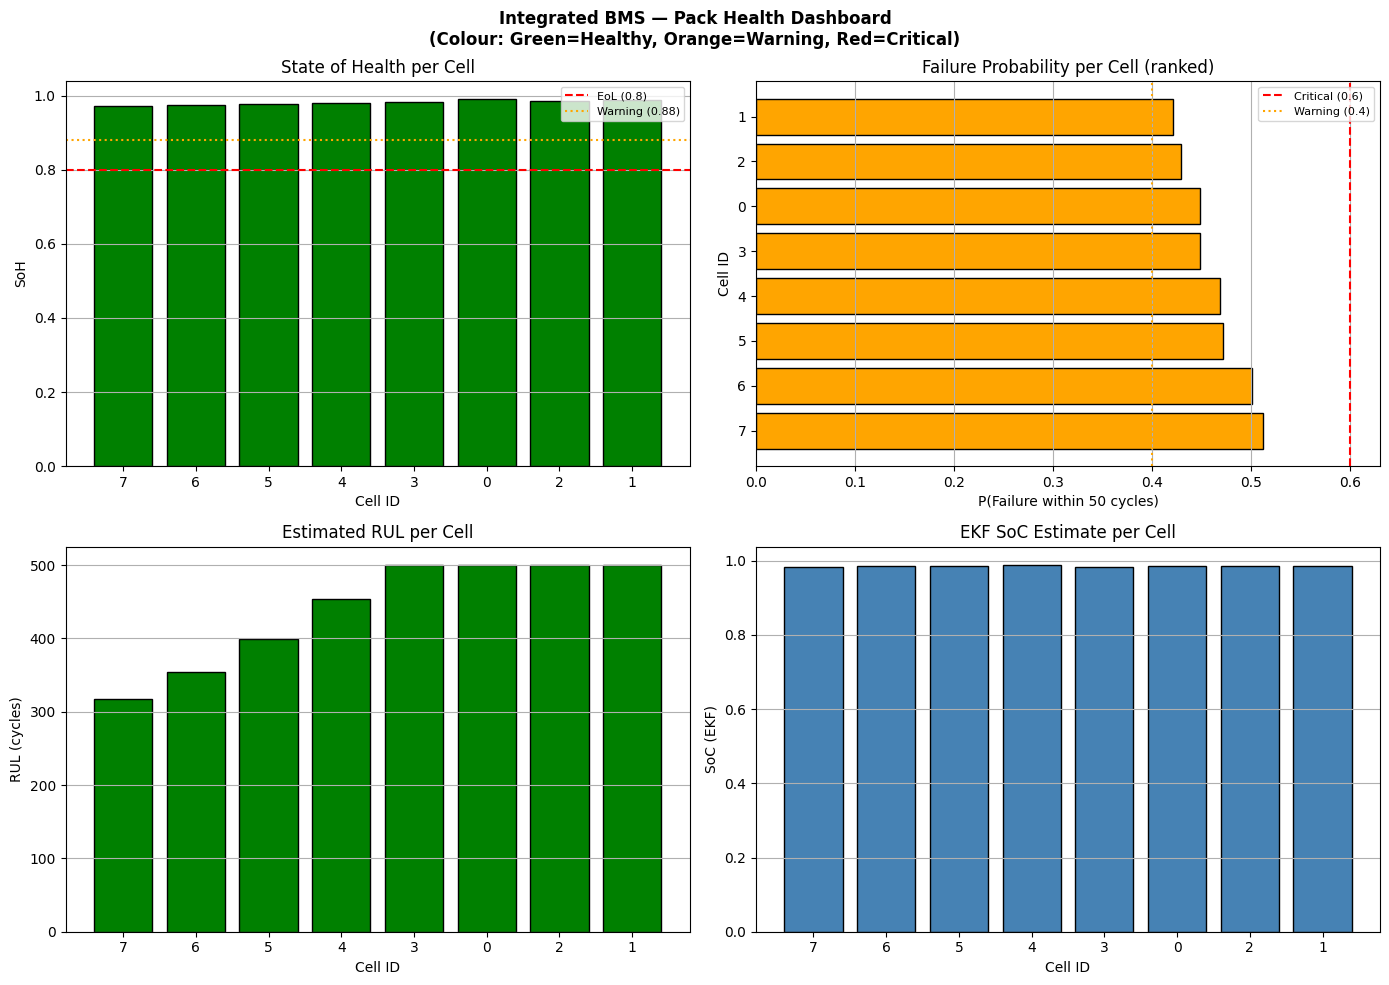


Health report saved.


In [ ]:
# ── Section 24: predict_pack_health() — Integrated BMS Health Report ──────────
print('=== Integrated Pack Health Report ===')

def predict_pack_health(pack_cells, initial_capacities,
                        clf_model, clf_scaler,
                        ekf_params=None):
    """
    Integrated BMS function that combines:
      - ECM-based voltage simulation
      - EKF SoC estimation
      - ML failure probability prediction
      - RUL estimation

    Returns a ranked health report for each cell in the pack.

    Parameters
    ----------
    pack_cells        : list of CellSimulator objects
    initial_capacities: list of initial capacities per cell
    clf_model         : trained failure classifier
    clf_scaler        : scaler for classifier features
    ekf_params        : dict with R0, R1, C1 for EKF (uses cell params if None)

    Returns
    -------
    report_df : DataFrame ranked by failure probability (worst first)
    """
    report = []

    for i, cell in enumerate(pack_cells):
        init_cap = initial_capacities[i]
        current_soh = cell.soh(init_cap)

        # Run one discharge cycle to get observables
        volt_c, socs_c, _ = simulate_pack_cycle(
            [cell], current_A=-1.0, dt=1.0, soc_cutoff=0.1)

        # EKF SoC estimation
        ekf = BatteryEKF(
            R0=cell.R0, R1=cell.R1, C1=cell.C1)
        soc_true = socs_c[0]
        I_profile = np.full(len(soc_true), -1.0)
        rng_ekf   = np.random.RandomState(i)
        V_meas    = (TheveninECM.ocv_from_soc(soc_true)
                     + rng_ekf.normal(0, 0.005, len(soc_true)))

        soc_ekf_vals = []
        for t in range(len(soc_true)):
            ekf.predict(I_profile[t])
            soc_est, _ = ekf.update(V_meas[t], I_profile[t])
            soc_ekf_vals.append(soc_est)

        soc_ekf_final = soc_ekf_vals[-1]

        # Failure probability
        v_drop   = volt_c[0].max() - volt_c[0].min()
        R0_est   = abs(volt_c[0][0] - volt_c[0][1]) / 1.0
        cap_fade = cell.capacity_fade / (cell.capacity + cell.capacity_fade + 1e-9)
        soc_range = socs_c[0].max() - socs_c[0].min()

        clf_feat = np.array([[v_drop, R0_est, cap_fade,
                               cell.V1, soc_range, current_soh]])
        clf_feat_sc   = clf_scaler.transform(clf_feat)
        failure_prob  = clf_model.predict_proba(clf_feat_sc)[0, 1]

        # Simple RUL estimate from SoH trend
        if current_soh > EOL_SOH:
            soh_deficit   = current_soh - EOL_SOH
            fade_per_cycle = max(cell.capacity_fade /
                                 max(cell.cycle, 1), 1e-6)
            rul_est = int(soh_deficit * init_cap / (fade_per_cycle + 1e-9))
            rul_est = min(rul_est, 500)
        else:
            rul_est = 0

        # Health status
        if failure_prob > 0.7 or current_soh < EOL_SOH:
            status = 'CRITICAL'
        elif failure_prob > 0.4 or current_soh < 0.88:
            status = 'WARNING'
        else:
            status = 'HEALTHY'

        report.append({
            'cell_id':       i,
            'soh':           round(current_soh, 4),
            'soc_ekf':       round(soc_ekf_final, 4),
            'failure_prob':  round(failure_prob, 4),
            'rul_cycles':    rul_est,
            'cap_fade_pct':  round(cap_fade * 100, 2),
            'status':        status
        })

    report_df = pd.DataFrame(report)
    report_df = report_df.sort_values('failure_prob', ascending=False)
    report_df = report_df.reset_index(drop=True)
    return report_df


# Reset pack cells to a degraded state for a meaningful demo
print('Applying 50 degradation cycles to pack for demo...')
deg_rates = [0.0002 + i * 0.00005 for i in range(N_CELLS)]  # varying rates

for cycle_n in range(50):
    simulate_pack_cycle(pack_cells, current_A=-1.0,
                        dt=1.0, soc_cutoff=0.1)
    for i, cell in enumerate(pack_cells):
        cell.apply_cycle_degradation(deg_rates[i])
        cell.soc = 1.0

print('Running integrated health report...')
health_report = predict_pack_health(
    pack_cells, initial_capacities,
    clf_rf, scaler_fail)

print('\n' + '=' * 65)
print('  PACK HEALTH REPORT (ranked by failure risk)')
print('=' * 65)
print(f'  {"Rank":<5} {"Cell":<6} {"SoH":>6} {"SoC(EKF)":>9} '
      f'{"P(Fail)":>8} {"RUL":>6} {"Fade%":>7} {"Status"}')
print(f'  {"-"*62}')
for rank, row in health_report.iterrows():
    print(f'  {rank+1:<5} {int(row["cell_id"]):<6} '
          f'{row["soh"]:>6.4f} {row["soc_ekf"]:>9.4f} '
          f'{row["failure_prob"]:>8.4f} {int(row["rul_cycles"]):>6} '
          f'{row["cap_fade_pct"]:>7.2f}% {row["status"]}')

# Dashboard plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: SoH per cell
colors_soh = ['red' if s < EOL_SOH else
               'orange' if s < 0.88 else 'green'
               for s in health_report['soh']]
axes[0,0].bar(health_report['cell_id'].astype(str),
              health_report['soh'], color=colors_soh, edgecolor='black')
axes[0,0].axhline(EOL_SOH, color='red', linestyle='--',
                   linewidth=1.5, label='EoL (0.8)')
axes[0,0].axhline(0.88,    color='orange', linestyle=':',
                   linewidth=1.5, label='Warning (0.88)')
axes[0,0].set_title('State of Health per Cell')
axes[0,0].set_xlabel('Cell ID')
axes[0,0].set_ylabel('SoH')
axes[0,0].legend(fontsize=8)
axes[0,0].grid(True, axis='y')

# Panel 2: Failure probability
colors_fp = ['red' if p > 0.7 else
              'orange' if p > 0.4 else 'green'
              for p in health_report['failure_prob']]
axes[0,1].barh(health_report['cell_id'].astype(str),
               health_report['failure_prob'],
               color=colors_fp, edgecolor='black')
axes[0,1].axvline(0.6, color='red', linestyle='--',
                   linewidth=1.5, label='Critical (0.6)')
axes[0,1].axvline(0.4, color='orange', linestyle=':',
                   linewidth=1.5, label='Warning (0.4)')
axes[0,1].set_title('Failure Probability per Cell (ranked)')
axes[0,1].set_xlabel('P(Failure within 50 cycles)')
axes[0,1].set_ylabel('Cell ID')
axes[0,1].legend(fontsize=8)
axes[0,1].grid(True, axis='x')

# Panel 3: RUL
colors_rul = ['red' if r < 20 else
               'orange' if r < 50 else 'green'
               for r in health_report['rul_cycles']]
axes[1,0].bar(health_report['cell_id'].astype(str),
              health_report['rul_cycles'],
              color=colors_rul, edgecolor='black')
axes[1,0].set_title('Estimated RUL per Cell')
axes[1,0].set_xlabel('Cell ID')
axes[1,0].set_ylabel('RUL (cycles)')
axes[1,0].grid(True, axis='y')

# Panel 4: EKF SoC per cell
colors_soc = ['red' if s < 0.2 else
               'orange' if s < 0.4 else 'steelblue'
               for s in health_report['soc_ekf']]
axes[1,1].bar(health_report['cell_id'].astype(str),
              health_report['soc_ekf'],
              color=colors_soc, edgecolor='black')
axes[1,1].set_title('EKF SoC Estimate per Cell')
axes[1,1].set_xlabel('Cell ID')
axes[1,1].set_ylabel('SoC (EKF)')
axes[1,1].grid(True, axis='y')

plt.suptitle('Integrated BMS — Pack Health Dashboard\n'
             '(Colour: Green=Healthy, Orange=Warning, Red=Critical)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/outputs/plots/pack_health_dashboard.png', dpi=150)
plt.show()

health_report.to_csv('/content/outputs/pack_health_report.csv', index=False)
print('\nHealth report saved.')

In [ ]:
# ── Updated Final Report (complete) ───────────────────────────────────────────
print('=' * 65)
print('  FINAL PROJECT REPORT')
print('  Design and Implementation of a Machine Learning Assisted')
print('  Battery Management System for Lithium-Ion Batteries')
print('  using NASA Battery Dataset')
print('=' * 65)

print('\n── Dataset ──────────────────────────────────────────────────')
print(f'  Source      : NASA Battery Dataset (Kaggle: mystifoe77)')
print(f'  Batteries   : B0005, B0006, B0007, B0018')
print(f'  Real rows   : {len(df_clean)} (after cleaning)')
print(f'  Synthetic   : 10,000 labelled + 5,000 sequence samples')
print(f'  Split       : 3 train / 1 test (battery-wise)')

print('\n── SoH Estimation Results ───────────────────────────────────')
soh_models = results_df[results_df['model'].str.contains(
    'Forest|XGB|GPR|SoH')]
print(f'  {"Model":<40} {"MAE":>7} {"RMSE":>7} {"R2":>7}')
print(f'  {"-"*61}')
for _, row in soh_models.iterrows():
    print(f'  {row["model"]:<40} {row["MAE"]:>7.4f} '
          f'{row["RMSE"]:>7.4f} {row["R2"]:>7.4f}')

print('\n── SoC Estimation Results ───────────────────────────────────')
soc_models = results_df[results_df['model'].str.contains('SoC|EKF')]
print(f'  {"Model":<40} {"MAE":>7} {"RMSE":>7} {"R2":>7}')
print(f'  {"-"*61}')
for _, row in soc_models.iterrows():
    print(f'  {row["model"]:<40} {row["MAE"]:>7.4f} '
          f'{row["RMSE"]:>7.4f} {row["R2"]:>7.4f}')

print('\n── Cell Failure Classification Results ──────────────────────')
print(f'  {"Model":<25} {"Acc":>6} {"Prec":>6} '
      f'{"Rec":>6} {"F1":>6} {"AUC":>6}')
print(f'  {"-"*57}')
for res in classifier_results:
    print(f'  {res["model"]:<25} {res["accuracy"]:>6.4f} '
          f'{res["precision"]:>6.4f} {res["recall"]:>6.4f} '
          f'{res["f1"]:>6.4f} {res["roc_auc"]:>6.4f}')
lstm_auc = roc_auc_score(y_lstm_test, y_prob_lstm)
print(f'  {"BiLSTM Classifier":<25} '
      f'{accuracy_score(y_lstm_test, y_pred_lstm_cls):>6.4f} '
      f'{precision_score(y_lstm_test, y_pred_lstm_cls, zero_division=0):>6.4f} '
      f'{recall_score(y_lstm_test, y_pred_lstm_cls, zero_division=0):>6.4f} '
      f'{f1_score(y_lstm_test, y_pred_lstm_cls, zero_division=0):>6.4f} '
      f'{lstm_auc:>6.4f}')

print('\n── Early Warning Detection (NASA Dataset) ───────────────────')
if avg_early > 0:
    print(f'  *** Average early warning: {avg_early:.1f} cycles '
          f'before actual EoL ***')
for bat_id, res in sorted(early_warning_results.items()):
    w = res["warning_cycle"]
    e = res["early_warning"]
    print(f'  Battery {bat_id}: warning at cycle {w}, '
          f'{e} cycles before EoL')

print('\n── Pack Health Report (8-Cell Simulator) ────────────────────')
print(f'  {"Cell":<6} {"SoH":>6} {"SoC":>6} '
      f'{"P(Fail)":>8} {"RUL":>6} {"Status"}')
print(f'  {"-"*45}')
for _, row in health_report.iterrows():
    print(f'  {int(row["cell_id"]):<6} {row["soh"]:>6.4f} '
          f'{row["soc_ekf"]:>6.4f} {row["failure_prob"]:>8.4f} '
          f'{int(row["rul_cycles"]):>6} {row["status"]}')

print('\n── Inference Latency ────────────────────────────────────────')
print(f'  Random Forest (SoH) : {rf_report["latency_ms"]:.3f} ms/sample')
print(f'  XGBoost (SoH)       : {xgb_report["latency_ms"]:.3f} ms/sample')
print(f'  BiLSTM (SoH)        : {lstm_report["latency_ms"]:.3f} ms/sample')
print(f'  BiLSTM (SoC)        : {soc_report["latency_ms"]:.3f} ms/sample')

print('\n── Key Design Decisions ─────────────────────────────────────')
print('  • Capacity excluded from ML inputs (leakage prevention)')
print('  • Resistance normalised to BOL for cross-battery generalisation')
print('  • Battery-wise split prevents cross-battery pattern leakage')
print('  • GPR residual correction provides uncertainty quantification')
print('  • EKF uses physics-based ECM — no data required for SoC')
print('  • 8-cell pack simulator with ±5% parameter variation')
print('  • 10,000 synthetic labelled samples for failure classification')
print('  • Early warning detection validated on real NASA data')

print('\n── Saved Artifacts ──────────────────────────────────────────')
for f in sorted(os.listdir('/content/models')):
    size_kb = os.path.getsize(f'/content/models/{f}') / 1024
    print(f'  {f} ({size_kb:.1f} KB)')

print('\n' + '=' * 65)
print('  Pipeline complete. All modules trained, evaluated, and saved.')
print('=' * 65)

  FINAL PROJECT REPORT
  Design and Implementation of a Machine Learning Assisted
  Battery Management System for Lithium-Ion Batteries
  using NASA Battery Dataset

── Dataset ──────────────────────────────────────────────────
  Source      : NASA Battery Dataset (Kaggle: mystifoe77)
  Batteries   : B0005, B0006, B0007, B0018
  Real rows   : 1984 (after cleaning)
  Synthetic   : 10,000 labelled + 5,000 sequence samples
  Split       : 3 train / 1 test (battery-wise)

── SoH Estimation Results ───────────────────────────────────
  Model                                        MAE    RMSE      R2
  -------------------------------------------------------------
  Random Forest (noisy)                     0.0103  0.0153  0.8085
  XGBoost (noisy)                           0.0190  0.0289  0.3116
  Hybrid RF + GPR                           0.0103  0.0153  0.8082
  BiLSTM + Attention (SoH)                  0.0268  0.0311  0.2120

── SoC Estimation Results ───────────────────────────────────
  M